# 04 — Classification v4 (Sentence Embeddings + Clean Features)
**Input:** `DATA_cleaned_v2.xlsx` → **Output:** `classification_v4_output.xlsx`

## Key changes vs v3
| Feature | v3 | v4 |
|---|---|---|
| Text representation | TF-IDF bag-of-words | Sentence-BERT embeddings (all-mpnet-base-v2) |
| Input quality | Partial cleaning | Full corpus cleaning (uLL→error, failue→failure, etc.) |
| SE / Regulatory flags | Not used | Clean binary features |
| Description 2 | Not used | Separate embedding stream |
| New keywords | 29 | 42 (tachycardia, stent, energy, investigation...) |
| New compound signals | 4 | 7 (ntf_patient, energy_low, tachycardia_sw) |

## Why sentence embeddings beat TF-IDF here
TF-IDF has no semantic understanding — 'pacing failure' and 'pacemaker not capturing'
are completely unrelated to it. Sentence-BERT encodes meaning into 768-dim vectors
where semantically similar phrases cluster together regardless of exact wording.
With only 133 positive examples, this generalisation is critical.

In [1]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (f1_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score, confusion_matrix)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
import lightgbm as lgb
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device} | Imports OK.')

Device: cpu | Imports OK.


In [2]:
INPUT_PATH  = 'DATA_cleaned_v2.xlsx'
OUTPUT_PATH = 'classification_v4_output.xlsx'

df_raw = pd.read_excel(INPUT_PATH)
df_raw = df_raw[df_raw['Important Event'].isin(['Yes','No'])].reset_index(drop=True)
y_all  = (df_raw['Important Event'] == 'Yes').astype(int)
print(f'Rows: {len(df_raw):,} | Yes: {y_all.sum()} ({y_all.mean()*100:.1f}%)')

idx_dev, idx_hold = train_test_split(np.arange(len(df_raw)), test_size=0.15, stratify=y_all, random_state=99)
df_dev,  df_hold  = df_raw.iloc[idx_dev].reset_index(drop=True), df_raw.iloc[idx_hold].reset_index(drop=True)
y_dev,   y_hold   = y_all.iloc[idx_dev].reset_index(drop=True), y_all.iloc[idx_hold].reset_index(drop=True)
print(f'Dev: {len(df_dev):,} (pos={y_dev.sum()}) | Holdout: {len(df_hold):,} (pos={y_hold.sum()})')
print('HOLDOUT LOCKED.')

Rows: 3,982 | Yes: 133 (3.3%)
Dev: 3,384 (pos=113) | Holdout: 598 (pos=20)
HOLDOUT LOCKED.


## Step 1 — Sentence Embeddings (replaces TF-IDF for sklearn models)

In [3]:
# Load sentence-transformer (already downloaded for BERTopic — reusing same model)
print('Loading sentence-transformer...')
sent_model = SentenceTransformer('all-mpnet-base-v2')
print('Model loaded.')

def get_stream(df, col):
    return df[col].fillna('').astype(str).tolist()

def embed_stream(texts, batch_size=128, desc=''):
    """Encode a list of texts into 768-dim sentence embeddings."""
    print(f'  Embedding {desc} ({len(texts)} texts)...')
    embs = sent_model.encode(texts, batch_size=batch_size,
                              show_progress_bar=True, convert_to_numpy=True)
    print(f'  Done. Shape: {embs.shape}')
    return embs

# Embed each text stream separately so models learn stream-specific weights
# This takes ~5-10 min total on CPU, ~1-2 min on GPU
print('\n=== Embedding text streams ===')
print('(Each stream is 768-dim. 5 streams = 3840 semantic features total)')

emb_desc1_dev  = embed_stream(get_stream(df_dev,  'desc1_clean_bert'), desc='desc1 dev')
emb_desc1_hold = embed_stream(get_stream(df_hold, 'desc1_clean_bert'), desc='desc1 holdout')

emb_prob_dev   = embed_stream(get_stream(df_dev,  'notes_problem_desc'), desc='problem_desc dev')
emb_prob_hold  = embed_stream(get_stream(df_hold, 'notes_problem_desc'), desc='problem_desc holdout')

emb_diag_dev   = embed_stream(get_stream(df_dev,  'notes_diagnostic'), desc='diagnostic dev')
emb_diag_hold  = embed_stream(get_stream(df_hold, 'notes_diagnostic'), desc='diagnostic holdout')

emb_resol_dev  = embed_stream(get_stream(df_dev,  'notes_resolution'), desc='resolution dev')
emb_resol_hold = embed_stream(get_stream(df_hold, 'notes_resolution'), desc='resolution holdout')

emb_desc2_dev  = embed_stream(get_stream(df_dev,  'desc2_clean_bert'), desc='desc2 dev')
emb_desc2_hold = embed_stream(get_stream(df_hold, 'desc2_clean_bert'), desc='desc2 holdout')

print('\nAll embeddings computed.')

Loading sentence-transformer...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1589.92it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.

=== Embedding text streams ===
(Each stream is 768-dim. 5 streams = 3840 semantic features total)
  Embedding desc1 dev (3384 texts)...


Batches: 100%|██████████| 27/27 [02:48<00:00,  6.22s/it]


  Done. Shape: (3384, 768)
  Embedding desc1 holdout (598 texts)...


...

  Done. Shape: (598, 768)
  Embedding desc2 dev (3384 texts)...


Batches: 100%|██████████| 27/27 [00:19<00:00,  1.40it/s]


  Done. Shape: (3384, 768)
  Embedding desc2 holdout (598 texts)...


Batches: 100%|██████████| 5/5 [00:03<00:00,  1.39it/s]

  Done. Shape: (598, 768)

All embeddings computed.


In [4]:
# ── Build numeric feature matrix ──────────────────────────────────────────
SEVERITY_KW = [
    'patient','injury','death','harm','adverse','incident','complaint','legal',
    'regulatory','recall','safety','malfunction','failure','critical','urgent',
    'emergency','shock','pacing','deliver','defibrillat','cardioversion',
    'life','sustain','serious','fatal','abort','spark','burn','smoke',
    'tachycardia','arrhythmia','cardiac','ventricular','fibrillation',
    'stent','catheter','energy','investigation','reportable','radiation',
]

def build_numeric(df):
    num = pd.DataFrame(index=df.index)
    for kw in SEVERITY_KW:
        col = f'kw_{kw}'
        num[col] = df[col].fillna(0) if col in df.columns else 0
    for sig in ['sig_shock_not_delivered','sig_pacing_failure','sig_patient_impact',
                'sig_critical_fail','sig_ntf_patient','sig_energy_low','sig_tachycardia_sw']:
        num[sig] = df[sig].fillna(0) if sig in df.columns else 0
    for col in ['hour_of_day','day_of_week','is_weekend','month','days_since_start',
                'desc1_word_count','desc2_word_count','notes_char_count',
                'notes_has_content','has_problem_desc','has_diagnostic',
                'desc_d2_longer','desc_len_diff']:
        num[col] = df[col].fillna(0) if col in df.columns else 0
    # SE flag and regulatory flag — treat NaN as 0 (not flagged)
    num['se_flag']         = df['se_flag'].fillna(0)         if 'se_flag'         in df.columns else 0
    num['regulatory_flag'] = df['regulatory_flag'].fillna(0) if 'regulatory_flag' in df.columns else 0
    # LDA topic probs (top 10)
    for col in sorted([c for c in df.columns if c.startswith('lda_prob_t')])[:10]:
        num[col] = df[col].fillna(0)
    return num

num_dev  = build_numeric(df_dev)
num_hold = build_numeric(df_hold)
print(f'Numeric features: {num_dev.shape[1]}')
print(f'  Including se_flag: {"se_flag" in num_dev.columns}')
print(f'  Including regulatory_flag: {"regulatory_flag" in num_dev.columns}')

Numeric features: 62
  Including se_flag: True
  Including regulatory_flag: True


In [5]:
# ── Combine embeddings + numeric into feature matrices ────────────────────
# Scale embeddings (important for LR convergence on 768-dim dense vectors)
scaler = StandardScaler()

# Stack all embedding streams horizontally
X_emb_dev  = np.hstack([emb_desc1_dev,  emb_prob_dev,  emb_diag_dev,  emb_resol_dev,  emb_desc2_dev])
X_emb_hold = np.hstack([emb_desc1_hold, emb_prob_hold, emb_diag_hold, emb_resol_hold, emb_desc2_hold])

X_emb_dev  = scaler.fit_transform(X_emb_dev)
X_emb_hold = scaler.transform(X_emb_hold)

# Full feature matrix: embeddings + numeric
X_dev  = np.hstack([X_emb_dev,  num_dev.values])
X_hold = np.hstack([X_emb_hold, num_hold.values])

print(f'Embedding features per row: {X_emb_dev.shape[1]}  (5 streams x 768)')
print(f'Numeric features per row:   {num_dev.shape[1]}')
print(f'Total feature matrix:        {X_dev.shape}')

Embedding features per row: 3840  (5 streams x 768)
Numeric features per row:   62
Total feature matrix:        (3384, 3902)


In [6]:
# ── Also keep a TF-IDF sparse matrix for LightGBM (trees work well with sparse) ─
# Hybrid approach: trees use sparse TF-IDF, LR uses dense embeddings
def get_streams_text(df):
    return {
        'desc':  df['desc1_clean_bert'].fillna('').astype(str),
        'prob':  df['notes_problem_desc'].fillna('').astype(str),
        'diag':  df['notes_diagnostic'].fillna('').astype(str),
        'resol': df['notes_resolution'].fillna('').astype(str),
        'notes': df['notes_clean'].fillna('').astype(str),
    }

def fit_tfidf(train_texts, max_features=600, ngram=(1,2)):
    vec = TfidfVectorizer(max_features=max_features, ngram_range=ngram,
                          token_pattern=r'\b[a-z]{3,}\b', sublinear_tf=True)
    return vec, vec.fit_transform(train_texts)

st_dev  = get_streams_text(df_dev)
st_hold = get_streams_text(df_hold)

vec_d, Xd_dev = fit_tfidf(st_dev['desc'],  500, (1,2))
vec_p, Xp_dev = fit_tfidf(st_dev['prob'],  500, (1,2))
vec_g, Xg_dev = fit_tfidf(st_dev['diag'],  300, (1,2))
vec_r, Xr_dev = fit_tfidf(st_dev['resol'], 300, (1,2))
vec_n, Xn_dev = fit_tfidf(st_dev['notes'], 800, (1,2))

Xd_ho = vec_d.transform(st_hold['desc'])
Xp_ho = vec_p.transform(st_hold['prob'])
Xg_ho = vec_g.transform(st_hold['diag'])
Xr_ho = vec_r.transform(st_hold['resol'])
Xn_ho = vec_n.transform(st_hold['notes'])

X_sp_dev  = hstack([Xd_dev, Xp_dev, Xg_dev, Xr_dev, Xn_dev, csr_matrix(num_dev.values)])
X_sp_hold = hstack([Xd_ho,  Xp_ho,  Xg_ho,  Xr_ho,  Xn_ho,  csr_matrix(num_hold.values)])

svd = TruncatedSVD(n_components=150, random_state=42)
X_svd_dev  = svd.fit_transform(X_sp_dev)
X_svd_hold = svd.transform(X_sp_hold)
print(f'Sparse (trees):   {X_sp_dev.shape}')
print(f'Dense SVD (XGB):  {X_svd_dev.shape}')
print(f'SVD var explained: {svd.explained_variance_ratio_.sum()*100:.1f}%')

Sparse (trees):   (3384, 2462)
Dense SVD (XGB):  (3384, 150)
SVD var explained: 100.0%


In [7]:
def find_thresholds(y_true, y_prob):
    prec, rec, threshs = precision_recall_curve(y_true, y_prob)
    f1s = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9)
    thresh_f1 = float(threshs[np.argmax(f1s)])
    thresh_recall = thresh_f1
    for p, r, t in zip(prec, rec, threshs):
        if p >= 0.20:
            thresh_recall = float(t)
            break
    return thresh_f1, thresh_recall

def evaluate_both(name, y_true, y_prob, tf1, trec, tag):
    rows = []
    for thresh, label in [(tf1,'F1-opt'),(trec,'Recall-opt')]:
        yp = (y_prob >= thresh).astype(int)
        r = recall_score(y_true,yp,zero_division=0)
        p = precision_score(y_true,yp,zero_division=0)
        f1= f1_score(y_true,yp,zero_division=0)
        pr= average_precision_score(y_true,y_prob)
        print(f'  {name:22s} [{label:11s}] recall={r:.3f}  prec={p:.3f}  f1={f1:.3f}  PR-AUC={pr:.3f}  t={thresh:.4f}  [{tag}]')
        rows.append({'model':name,'mode':label,'smote':tag,'recall':r,'precision':p,'f1':f1,'pr_auc':pr,'threshold':thresh})
    return rows

def oof_cv(model, X, y, folds=5):
    return cross_val_predict(model, X, np.array(y),
        cv=StratifiedKFold(folds,shuffle=True,random_state=42), method='predict_proba')[:,1]

def smote_only(X, y):
    try: return SMOTE(random_state=42, k_neighbors=3).fit_resample(X, y)
    except: return X, np.array(y)

def smoteenn(X, y):
    try: return SMOTEENN(random_state=42).fit_resample(X, y)
    except: return X, np.array(y)

neg_pos = (y_dev==0).sum()/(y_dev==1).sum()
print(f'Class ratio: {neg_pos:.0f}:1')
results_all = []

Class ratio: 29:1


## Step 2 — Logistic Regression on Sentence Embeddings
LR on 3840-dim sentence embeddings is a very strong baseline — it's essentially a
semantic similarity classifier. With embeddings, LR is no longer limited by vocabulary
overlap and can generalise across paraphrases.

In [8]:
print('=== LR on Sentence Embeddings ===')
lr = LogisticRegression(C=0.1, max_iter=2000, class_weight='balanced', solver='saga', random_state=42)
lr.fit(X_dev, y_dev)
oof_lr = oof_cv(lr, X_dev, y_dev)
tf1_lr, trec_lr = find_thresholds(y_dev.values, oof_lr)
results_all += evaluate_both('LR-Embeddings', y_dev.values, oof_lr, tf1_lr, trec_lr, 'no-smote')

# SMOTEENN for LR (linear boundary benefits from ENN cleaning)
X_sm, y_sm = smoteenn(X_dev, y_dev.values)
lr_sm = LogisticRegression(C=0.1, max_iter=2000, class_weight='balanced', solver='saga', random_state=42)
lr_sm.fit(X_sm, y_sm)
oof_lr_sm = oof_cv(lr_sm, X_dev, y_dev.values)
tf1_lr_sm, trec_lr_sm = find_thresholds(y_dev.values, oof_lr_sm)
results_all += evaluate_both('LR-Embeddings', y_dev.values, oof_lr_sm, tf1_lr_sm, trec_lr_sm, 'smoteenn')

=== LR on Sentence Embeddings ===


  LR-Embeddings          [F1-opt     ] recall=0.504  prec=0.298  f1=0.375  PR-AUC=0.269  t=0.7309  [no-smote]
  LR-Embeddings          [Recall-opt ] recall=0.637  prec=0.200  f1=0.304  PR-AUC=0.269  t=0.6661  [no-smote]
  LR-Embeddings          [F1-opt     ] recall=0.504  prec=0.298  f1=0.375  PR-AUC=0.269  t=0.7309  [smoteenn]
  LR-Embeddings          [Recall-opt ] recall=0.637  prec=0.200  f1=0.304  PR-AUC=0.269  t=0.6661  [smoteenn]


In [9]:
print('=== LightGBM on TF-IDF sparse (trees work better with sparse) ===')
def lgbm_fn(spw=None):
    return lgb.LGBMClassifier(
        n_estimators=1000, max_depth=6, learning_rate=0.02, num_leaves=40,
        subsample=0.8, colsample_bytree=0.7, min_child_samples=8,
        reg_alpha=0.1, reg_lambda=0.1,
        scale_pos_weight=spw if spw else neg_pos,
        random_state=42, verbose=-1
    )

lgbm_m = lgbm_fn(); lgbm_m.fit(X_sp_dev, y_dev)
oof_lgbm = oof_cv(lgbm_m, X_sp_dev, y_dev)
tf1_lgbm, trec_lgbm = find_thresholds(y_dev.values, oof_lgbm)
results_all += evaluate_both('LightGBM-TFIDF', y_dev.values, oof_lgbm, tf1_lgbm, trec_lgbm, 'no-smote')

X_sm_lg, y_sm_lg = smote_only(X_sp_dev, y_dev.values)
lgbm_sm = lgbm_fn(spw=1.0); lgbm_sm.fit(X_sm_lg, y_sm_lg)
oof_lgbm_sm = oof_cv(lgbm_sm, X_sp_dev, y_dev.values)
tf1_lgbm_sm, trec_lgbm_sm = find_thresholds(y_dev.values, oof_lgbm_sm)
results_all += evaluate_both('LightGBM-TFIDF', y_dev.values, oof_lgbm_sm, tf1_lgbm_sm, trec_lgbm_sm, 'smote-only')

=== LightGBM on TF-IDF sparse (trees work better with sparse) ===


  LightGBM-TFIDF         [F1-opt     ] recall=0.513  prec=0.439  f1=0.473  PR-AUC=0.448  t=0.3472  [no-smote]
  LightGBM-TFIDF         [Recall-opt ] recall=0.770  prec=0.200  f1=0.318  PR-AUC=0.448  t=0.0671  [no-smote]
  LightGBM-TFIDF         [F1-opt     ] recall=0.566  prec=0.408  f1=0.474  PR-AUC=0.452  t=0.0454  [smote-only]
  LightGBM-TFIDF         [Recall-opt ] recall=0.796  prec=0.200  f1=0.320  PR-AUC=0.452  t=0.0086  [smote-only]


In [10]:
print('=== LightGBM on Embeddings (compare with TF-IDF above) ===')
lgbm_emb = lgbm_fn(); lgbm_emb.fit(X_dev, y_dev)
oof_lgbm_emb = oof_cv(lgbm_emb, X_dev, y_dev)
tf1_lgbm_emb, trec_lgbm_emb = find_thresholds(y_dev.values, oof_lgbm_emb)
results_all += evaluate_both('LightGBM-Emb', y_dev.values, oof_lgbm_emb, tf1_lgbm_emb, trec_lgbm_emb, 'no-smote')

=== LightGBM on Embeddings (compare with TF-IDF above) ===


  LightGBM-Emb           [F1-opt     ] recall=0.558  prec=0.441  f1=0.492  PR-AUC=0.491  t=0.0267  [no-smote]
  LightGBM-Emb           [Recall-opt ] recall=0.814  prec=0.200  f1=0.321  PR-AUC=0.491  t=0.0013  [no-smote]


In [11]:
print('=== XGBoost on SVD-compressed TF-IDF ===')
xgb_base = XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.7, scale_pos_weight=neg_pos,
    eval_metric='logloss', random_state=42, verbosity=0)
xgb_m = CalibratedClassifierCV(xgb_base, method='isotonic', cv=3)
xgb_m.fit(X_svd_dev, y_dev)
oof_xgb = oof_cv(xgb_m, X_svd_dev, y_dev)
tf1_xgb, trec_xgb = find_thresholds(y_dev.values, oof_xgb)
results_all += evaluate_both('XGBoost-SVD', y_dev.values, oof_xgb, tf1_xgb, trec_xgb, 'no-smote')

X_sm_xg, y_sm_xg = smote_only(X_svd_dev, y_dev.values)
xgb_sm = CalibratedClassifierCV(
    XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7, scale_pos_weight=1,
        eval_metric='logloss', random_state=42, verbosity=0),
    method='isotonic', cv=3)
xgb_sm.fit(X_sm_xg, y_sm_xg)
oof_xgb_sm = oof_cv(xgb_sm, X_svd_dev, y_dev.values)
tf1_xgb_sm, trec_xgb_sm = find_thresholds(y_dev.values, oof_xgb_sm)
results_all += evaluate_both('XGBoost-SVD', y_dev.values, oof_xgb_sm, tf1_xgb_sm, trec_xgb_sm, 'smote-only')

=== XGBoost on SVD-compressed TF-IDF ===
  XGBoost-SVD            [F1-opt     ] recall=0.513  prec=0.430  f1=0.468  PR-AUC=0.420  t=0.1243  [no-smote]
  XGBoost-SVD            [Recall-opt ] recall=0.708  prec=0.201  f1=0.312  PR-AUC=0.420  t=0.0534  [no-smote]
  XGBoost-SVD            [F1-opt     ] recall=0.407  prec=0.517  f1=0.455  PR-AUC=0.416  t=0.2016  [smote-only]
  XGBoost-SVD            [Recall-opt ] recall=0.717  prec=0.200  f1=0.313  PR-AUC=0.416  t=0.0531  [smote-only]


In [12]:
# ── DistilBERT (class-weight loss, clean input) ───────────────────────────
print('Setting up DistilBERT...')
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def build_bert_input(df):
    """Build BERT input from cleaned text streams. v2 cleaning = better quality input."""
    texts = []
    for _, row in df.iterrows():
        d = str(row.get('desc1_clean_bert','')).strip()
        p = str(row.get('notes_problem_desc','')).strip()
        g = str(row.get('notes_diagnostic','')).strip()
        d2= str(row.get('desc2_clean_bert','')).strip()
        parts = []
        if d and d!='nan': parts.append(f'description: {d}')
        # Add D2 if it differs meaningfully from D1
        if d2 and d2!='nan' and d2!=d and len(d2)>10: parts.append(f'detail: {d2[:150]}')
        if p and p!='nan' and len(p)>10: parts.append(f'problem: {p[:350]}')
        if g and g!='nan' and len(g)>10: parts.append(f'diagnostic: {g[:200]}')
        texts.append(' | '.join(parts) if parts else 'no description')
    return texts

bert_texts_dev  = build_bert_input(df_dev)
bert_texts_hold = build_bert_input(df_hold)
print(f'Avg BERT input: {np.mean([len(t.split()) for t in bert_texts_dev]):.0f} words  (v1 was 47)')

class NoteDataset(Dataset):
    def __init__(self, texts, labels, max_len=256):
        self.texts, self.labels, self.max_len = texts, labels, max_len
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], max_length=self.max_len, truncation=True,
                        padding='max_length', return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels': torch.tensor(self.labels[i], dtype=torch.long)}

bert_tr_idx, bert_val_idx = train_test_split(np.arange(len(y_dev)), test_size=0.2, stratify=y_dev, random_state=11)
bert_tr_y  = y_dev.values[bert_tr_idx]
bert_val_y = y_dev.values[bert_val_idx]
train_ds = NoteDataset([bert_texts_dev[i] for i in bert_tr_idx], bert_tr_y.tolist())
val_ds   = NoteDataset([bert_texts_dev[i] for i in bert_val_idx], bert_val_y.tolist())
hold_ds  = NoteDataset(bert_texts_hold, y_hold.values.tolist())
print(f'BERT train={len(train_ds)} | val={len(val_ds)} | holdout={len(hold_ds)}')

Setting up DistilBERT...
Avg BERT input: 53 words  (v1 was 47)
BERT train=2707 | val=677 | holdout=598


In [13]:
pos_weight = (len(bert_tr_y)-int(sum(bert_tr_y)))/int(sum(bert_tr_y))
cw = torch.tensor([1.0, pos_weight], dtype=torch.float).to(device)
print(f'BERT class weight: {pos_weight:.1f}x')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(weight=cw)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
training_args = TrainingArguments(
    output_dir='./bert_v4', num_train_epochs=5, per_device_train_batch_size=16,
    per_device_eval_batch_size=32, learning_rate=2e-5, weight_decay=0.01,
    eval_strategy='epoch', save_strategy='no', load_best_model_at_end=False,
    logging_steps=50, report_to='none', use_cpu=(device=='cpu')
)
trainer = WeightedTrainer(model=bert_model, args=training_args,
                          train_dataset=train_ds, eval_dataset=val_ds)
print('Training DistilBERT  (~5-20 min)...')
trainer.train()
print('Done.')

BERT class weight: 29.1x


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4126.79it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training DistilBERT  (~5-20 min)...


Epoch,Training Loss,Validation Loss
1,0.876224,1.127123
2,0.724268,0.712661
3,0.468809,0.737622
4,0.220567,0.871481
5,0.174384,0.805908


Done.


In [14]:
def get_bert_probs(ds):
    out = trainer.predict(ds)
    return torch.nn.functional.softmax(torch.tensor(out.predictions), dim=1).numpy()[:,1]

val_probs_bert = get_bert_probs(val_ds)
tf1_bert, trec_bert = find_thresholds(bert_val_y, val_probs_bert)
results_all += evaluate_both('DistilBERT', bert_val_y, val_probs_bert, tf1_bert, trec_bert, 'class-weight')

  DistilBERT             [F1-opt     ] recall=0.565  prec=0.650  f1=0.605  PR-AUC=0.635  t=0.9425  [class-weight]
  DistilBERT             [Recall-opt ] recall=0.957  prec=0.200  f1=0.331  PR-AUC=0.635  t=0.0036  [class-weight]


In [15]:
# ── Stacking meta-learner ─────────────────────────────────────────────────
print('Training stacking meta-learner...')
kw_cols = ['kw_patient','kw_shock','kw_pacing','kw_death','kw_harm',
           'sig_shock_not_delivered','sig_pacing_failure','sig_patient_impact',
           'sig_ntf_patient','sig_energy_low','se_flag','regulatory_flag']

def safe_cols(num_df, cols):
    return np.hstack([num_df[c].values.reshape(-1,1) if c in num_df.columns
                      else np.zeros((len(num_df),1)) for c in cols])

meta_kw_dev  = safe_cols(num_dev,  kw_cols)
meta_kw_hold = safe_cols(num_hold, kw_cols)
meta_dev     = np.column_stack([oof_lr, oof_lgbm, oof_xgb, oof_lgbm_emb, meta_kw_dev])

meta_lr_m = LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced', random_state=42)
meta_lr_m.fit(meta_dev, y_dev)
oof_stack = cross_val_predict(meta_lr_m, meta_dev, y_dev.values,
                               cv=StratifiedKFold(5,shuffle=True,random_state=42),
                               method='predict_proba')[:,1]
tf1_stack, trec_stack = find_thresholds(y_dev.values, oof_stack)
results_all += evaluate_both('Stacking-LR', y_dev.values, oof_stack, tf1_stack, trec_stack, 'no-smote')

df_dev_res = pd.DataFrame(results_all)
f1_mask = df_dev_res['mode']=='F1-opt'
print('\n=== Dev OOF — F1-opt (sorted by F1) ===')
print(df_dev_res[f1_mask].sort_values('f1',ascending=False)[['model','smote','recall','precision','f1','pr_auc']].to_string(index=False))

Training stacking meta-learner...
  Stacking-LR            [F1-opt     ] recall=0.496  prec=0.566  f1=0.528  PR-AUC=0.471  t=0.8321  [no-smote]
  Stacking-LR            [Recall-opt ] recall=0.788  prec=0.200  f1=0.319  PR-AUC=0.471  t=0.4926  [no-smote]

=== Dev OOF — F1-opt (sorted by F1) ===
         model        smote   recall  precision       f1   pr_auc
    DistilBERT class-weight 0.565217   0.650000 0.604651 0.635204
   Stacking-LR     no-smote 0.495575   0.565657 0.528302 0.471085
  LightGBM-Emb     no-smote 0.557522   0.440559 0.492188 0.490723
LightGBM-TFIDF   smote-only 0.566372   0.407643 0.474074 0.451598
LightGBM-TFIDF     no-smote 0.513274   0.439394 0.473469 0.447504
   XGBoost-SVD     no-smote 0.513274   0.429630 0.467742 0.419959
   XGBoost-SVD   smote-only 0.407080   0.516854 0.455446 0.416133
 LR-Embeddings     no-smote 0.504425   0.298429 0.375000 0.269242
 LR-Embeddings     smoteenn 0.504425   0.298429 0.375000 0.269242


In [16]:
# ── HOLDOUT ───────────────────────────────────────────────────────────────
print('='*65)
print('HOLDOUT EVALUATION')
print('='*65)
y_ho = y_hold.values

prob_lr_ho      = lr.predict_proba(X_hold)[:,1]
prob_lr_sm_ho   = lr_sm.predict_proba(X_hold)[:,1]
prob_lgbm_ho    = lgbm_m.predict_proba(X_sp_hold)[:,1]
prob_lgbm_sm_ho = lgbm_sm.predict_proba(X_sp_hold)[:,1]
prob_lgbm_emb_ho= lgbm_emb.predict_proba(X_hold)[:,1]
prob_xgb_ho     = xgb_m.predict_proba(X_svd_hold)[:,1]
prob_xgb_sm_ho  = xgb_sm.predict_proba(X_svd_hold)[:,1]
prob_bert_ho    = get_bert_probs(hold_ds)

meta_hold_real  = np.column_stack([prob_lr_ho, prob_lgbm_ho, prob_xgb_ho, prob_lgbm_emb_ho,
                                    safe_cols(num_hold, kw_cols)])
prob_stack_ho   = meta_lr_m.predict_proba(meta_hold_real)[:,1]

ho_results = []
for name, prob, tf1, trec, tag in [
    ('LR-Embeddings',  prob_lr_ho,       tf1_lr,         trec_lr,         'no-smote'),
    ('LR-Embeddings',  prob_lr_sm_ho,    tf1_lr_sm,      trec_lr_sm,      'smoteenn'),
    ('LightGBM-TFIDF', prob_lgbm_ho,     tf1_lgbm,       trec_lgbm,       'no-smote'),
    ('LightGBM-TFIDF', prob_lgbm_sm_ho,  tf1_lgbm_sm,    trec_lgbm_sm,    'smote-only'),
    ('LightGBM-Emb',   prob_lgbm_emb_ho, tf1_lgbm_emb,   trec_lgbm_emb,   'no-smote'),
    ('XGBoost-SVD',    prob_xgb_ho,      tf1_xgb,        trec_xgb,        'no-smote'),
    ('XGBoost-SVD',    prob_xgb_sm_ho,   tf1_xgb_sm,     trec_xgb_sm,     'smote-only'),
    ('DistilBERT',     prob_bert_ho,     tf1_bert,       trec_bert,       'class-weight'),
    ('Stacking-LR',    prob_stack_ho,    tf1_stack,      trec_stack,      'no-smote'),
]:
    ho_results += evaluate_both(name, y_ho, prob, tf1, trec, tag)

# PR-AUC weighted ensemble
w = {
    'lr':       average_precision_score(y_dev.values, oof_lr),
    'lgbm':     average_precision_score(y_dev.values, oof_lgbm),
    'lgbm_emb': average_precision_score(y_dev.values, oof_lgbm_emb),
    'xgb':      average_precision_score(y_dev.values, oof_xgb),
    'bert':     average_precision_score(bert_val_y,   val_probs_bert),
    'stack':    average_precision_score(y_dev.values, oof_stack),
}
tw = sum(w.values()); W = {k: v/tw for k,v in w.items()}
print(f'\nWeights: {" ".join(f"{k}={v:.3f}" for k,v in W.items())}')

prob_ens_ho = sum(W[k]*p for k,p in zip(
    ['lr','lgbm','lgbm_emb','xgb','bert','stack'],
    [prob_lr_ho, prob_lgbm_ho, prob_lgbm_emb_ho, prob_xgb_ho, prob_bert_ho, prob_stack_ho]))
prob_ens_oof= (W['lr']*oof_lr+W['lgbm']*oof_lgbm+W['lgbm_emb']*oof_lgbm_emb+W['xgb']*oof_xgb+W['stack']*oof_stack)
prob_ens_norm = prob_ens_oof/(W['lr']+W['lgbm']+W['lgbm_emb']+W['xgb']+W['stack'])
tf1_ens, trec_ens = find_thresholds(y_dev.values, prob_ens_norm)
ho_results += evaluate_both('Ensemble', y_ho, prob_ens_ho, tf1_ens, trec_ens, 'no-smote')

df_ho = pd.DataFrame(ho_results)
f1m  = df_ho['mode']=='F1-opt'
recm = df_ho['mode']=='Recall-opt'
print('\n=== HOLDOUT F1-optimised ===')
print(df_ho[f1m].sort_values('f1',ascending=False)[['model','smote','recall','precision','f1','pr_auc','threshold']].to_string(index=False))
print('\n=== HOLDOUT Recall-optimised ===')
print(df_ho[recm].sort_values(['recall','f1'],ascending=False)[['model','smote','recall','precision','f1','pr_auc','threshold']].to_string(index=False))

HOLDOUT EVALUATION


  LR-Embeddings          [F1-opt     ] recall=0.600  prec=0.286  f1=0.387  PR-AUC=0.383  t=0.7309  [no-smote]
  LR-Embeddings          [Recall-opt ] recall=0.750  prec=0.224  f1=0.345  PR-AUC=0.383  t=0.6661  [no-smote]
  LR-Embeddings          [F1-opt     ] recall=0.650  prec=0.271  f1=0.382  PR-AUC=0.417  t=0.7309  [smoteenn]
  LR-Embeddings          [Recall-opt ] recall=0.700  prec=0.219  f1=0.333  PR-AUC=0.417  t=0.6661  [smoteenn]
  LightGBM-TFIDF         [F1-opt     ] recall=0.700  prec=0.412  f1=0.519  PR-AUC=0.546  t=0.3472  [no-smote]
  LightGBM-TFIDF         [Recall-opt ] recall=0.800  prec=0.155  f1=0.260  PR-AUC=0.546  t=0.0671  [no-smote]
  LightGBM-TFIDF         [F1-opt     ] recall=0.800  prec=0.333  f1=0.471  PR-AUC=0.610  t=0.0454  [smote-only]
  LightGBM-TFIDF         [Recall-opt ] recall=0.850  prec=0.145  f1=0.248  PR-AUC=0.610  t=0.0086  [smote-only]
  LightGBM-Emb           [F1-opt     ] recall=0.500  prec=0.385  f1=0.435  PR-AUC=0.515  t=0.0267  [no-smote]
  Ligh

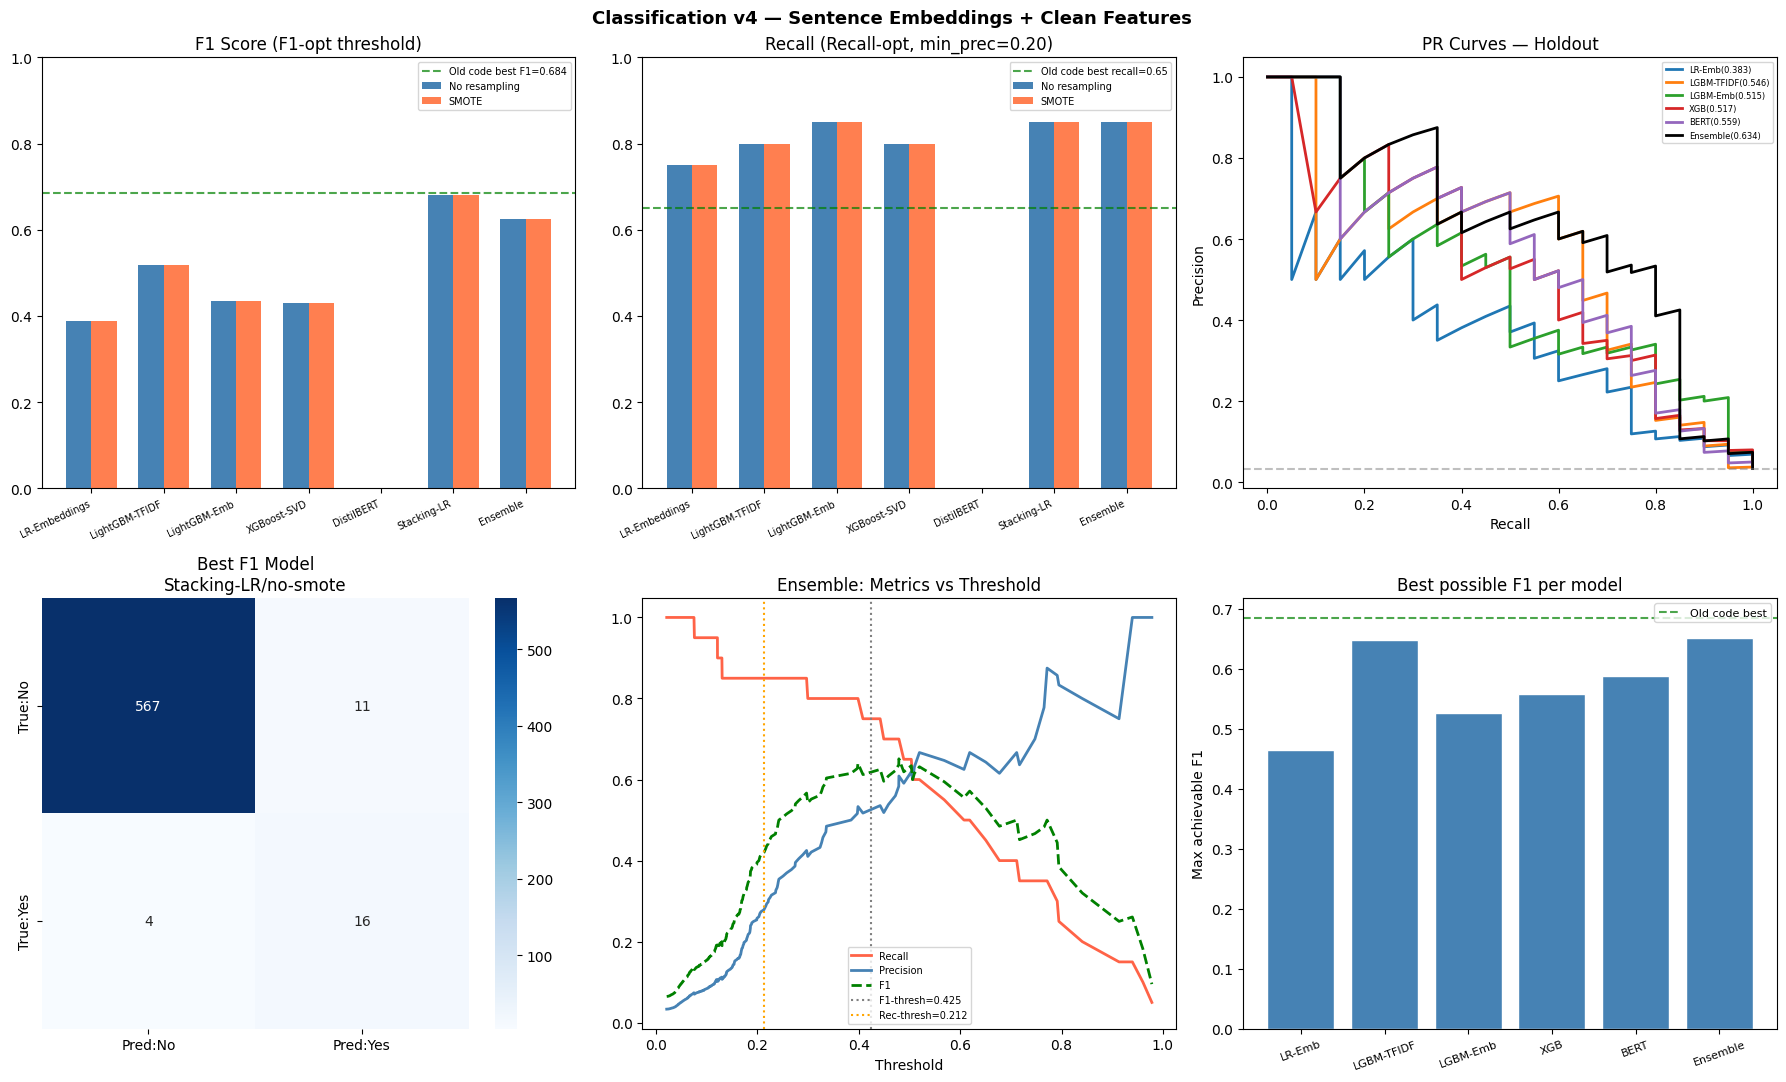

Saved: classification_v4_evaluation.png


In [17]:
# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18,11))
fig.suptitle('Classification v4 — Sentence Embeddings + Clean Features', fontsize=13, fontweight='bold')

models_list = ['LR-Embeddings','LightGBM-TFIDF','LightGBM-Emb','XGBoost-SVD','DistilBERT','Stacking-LR','Ensemble']
def gm(df, model, smote_kw, mode_val, metric):
    row = df[(df['model']==model)&(df['smote'].str.contains(smote_kw,regex=False))&(df['mode']==mode_val)]
    return row[metric].values[0] if len(row) else 0

x = np.arange(len(models_list)); bw=0.35

ax=axes[0,0]
f1_no=[gm(df_ho,m,'no-smote','F1-opt','f1') for m in models_list]
f1_sm=[gm(df_ho,m,'smote','F1-opt','f1') for m in models_list]
ax.bar(x-bw/2,f1_no,bw,label='No resampling',color='steelblue')
ax.bar(x+bw/2,f1_sm,bw,label='SMOTE',color='coral')
ax.axhline(0.684,ls='--',color='green',alpha=0.7,label='Old code best F1=0.684')
ax.set_xticks(x); ax.set_xticklabels(models_list,rotation=25,ha='right',fontsize=7)
ax.set_title('F1 Score (F1-opt threshold)'); ax.legend(fontsize=7); ax.set_ylim(0,1)

ax=axes[0,1]
rec_no=[gm(df_ho,m,'no-smote','Recall-opt','recall') for m in models_list]
rec_sm=[gm(df_ho,m,'smote','Recall-opt','recall') for m in models_list]
ax.bar(x-bw/2,rec_no,bw,label='No resampling',color='steelblue')
ax.bar(x+bw/2,rec_sm,bw,label='SMOTE',color='coral')
ax.axhline(0.65,ls='--',color='green',alpha=0.7,label='Old code best recall=0.65')
ax.set_xticks(x); ax.set_xticklabels(models_list,rotation=25,ha='right',fontsize=7)
ax.set_title('Recall (Recall-opt, min_prec=0.20)'); ax.legend(fontsize=7); ax.set_ylim(0,1)

ax=axes[0,2]
for name, prob, color in [
    ('LR-Emb',prob_lr_ho,'#1f77b4'),('LGBM-TFIDF',prob_lgbm_ho,'#ff7f0e'),
    ('LGBM-Emb',prob_lgbm_emb_ho,'#2ca02c'),('XGB',prob_xgb_ho,'#d62728'),
    ('BERT',prob_bert_ho,'#9467bd'),('Ensemble',prob_ens_ho,'black')]:
    p,r,_=precision_recall_curve(y_ho,prob)
    ax.plot(r,p,lw=2,color=color,label=f'{name}({average_precision_score(y_ho,prob):.3f})')
ax.axhline(y_ho.mean(),ls='--',color='gray',alpha=0.5)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curves — Holdout'); ax.legend(fontsize=6)

best_f1 = df_ho[f1m].sort_values('f1',ascending=False).iloc[0]
prob_map={'LR-Embeddings/no-smote':prob_lr_ho,'LR-Embeddings/smoteenn':prob_lr_sm_ho,
          'LightGBM-TFIDF/no-smote':prob_lgbm_ho,'LightGBM-TFIDF/smote-only':prob_lgbm_sm_ho,
          'LightGBM-Emb/no-smote':prob_lgbm_emb_ho,'XGBoost-SVD/no-smote':prob_xgb_ho,
          'XGBoost-SVD/smote-only':prob_xgb_sm_ho,'DistilBERT/class-weight':prob_bert_ho,
          'Stacking-LR/no-smote':prob_stack_ho,'Ensemble/no-smote':prob_ens_ho}
bkey = f'{best_f1["model"]}/{best_f1["smote"]}'
bprob= prob_map.get(bkey, prob_ens_ho)
bpred= (bprob>=best_f1['threshold']).astype(int)
ax=axes[1,0]
sns.heatmap(confusion_matrix(y_ho,bpred),annot=True,fmt='d',cmap='Blues',ax=ax,
            xticklabels=['Pred:No','Pred:Yes'],yticklabels=['True:No','True:Yes'])
ax.set_title(f'Best F1 Model\n{bkey}')

ax=axes[1,1]
p_a,r_a,t_a=precision_recall_curve(y_ho,prob_ens_ho)
f1_a=2*p_a[:-1]*r_a[:-1]/(p_a[:-1]+r_a[:-1]+1e-9)
ax.plot(t_a,r_a[:-1],label='Recall',color='tomato',lw=2)
ax.plot(t_a,p_a[:-1],label='Precision',color='steelblue',lw=2)
ax.plot(t_a,f1_a,label='F1',color='green',lw=2,ls='--')
ax.axvline(tf1_ens,ls=':',color='gray',label=f'F1-thresh={tf1_ens:.3f}')
ax.axvline(trec_ens,ls=':',color='orange',label=f'Rec-thresh={trec_ens:.3f}')
ax.set_xlabel('Threshold'); ax.set_title('Ensemble: Metrics vs Threshold'); ax.legend(fontsize=7)

ax=axes[1,2]
models_pr = ['LR-Emb','LGBM-TFIDF','LGBM-Emb','XGB','BERT','Ensemble']
prob_list = [prob_lr_ho,prob_lgbm_ho,prob_lgbm_emb_ho,prob_xgb_ho,prob_bert_ho,prob_ens_ho]
f1_bars = []
for prob in prob_list:
    p,r,t=precision_recall_curve(y_ho,prob)
    f1s=2*p[:-1]*r[:-1]/(p[:-1]+r[:-1]+1e-9)
    f1_bars.append(f1s.max())
ax.bar(models_pr,f1_bars,color='steelblue',edgecolor='white')
ax.axhline(0.684,ls='--',color='green',alpha=0.7,label='Old code best')
ax.set_ylabel('Max achievable F1'); ax.set_title('Best possible F1 per model')
ax.legend(fontsize=8)
[ax.tick_params(axis='x',rotation=20,labelsize=8) for ax in [axes[1,2]]]

plt.tight_layout()
plt.savefig('classification_v4_evaluation.png',dpi=150,bbox_inches='tight')
plt.show(); print('Saved: classification_v4_evaluation.png')



════════════════════════════════════════════════════════════════════════
  CLASSIFICATION REPORTS — HOLDOUT SET (598 rows, 20 Important Events)
════════════════════════════════════════════════════════════════════════
  Each model shown at two operating points:
  [F1-opt]     — threshold that maximises F1 score
  [Recall-opt] — threshold that maximises recall (min precision=0.20)
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
  LR-Embeddings  [no-smote]  —  threshold: 0.7309  (F1-opt)
════════════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      No (0)      0.986     0.948     0.966       578
     Yes (1)      0.286     0.600     0.387        20

    accuracy                          0.936       598
   macro avg      0.636     0.774     0.677       598
weighted avg      0.962     0.936     0.947       598

  Confusi

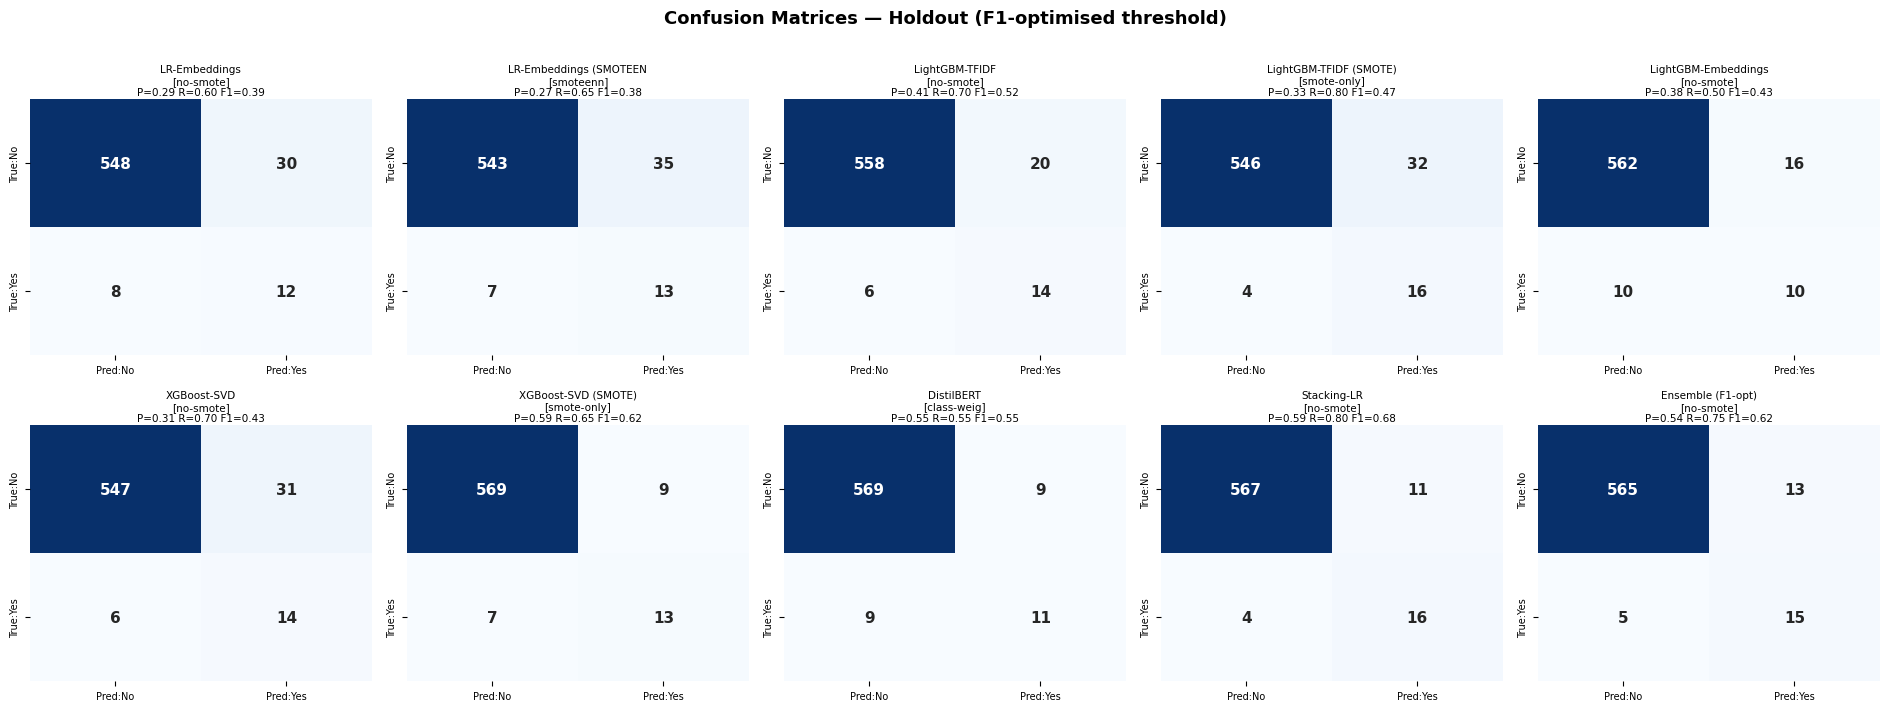


Saved: confusion_matrices_all_models.png


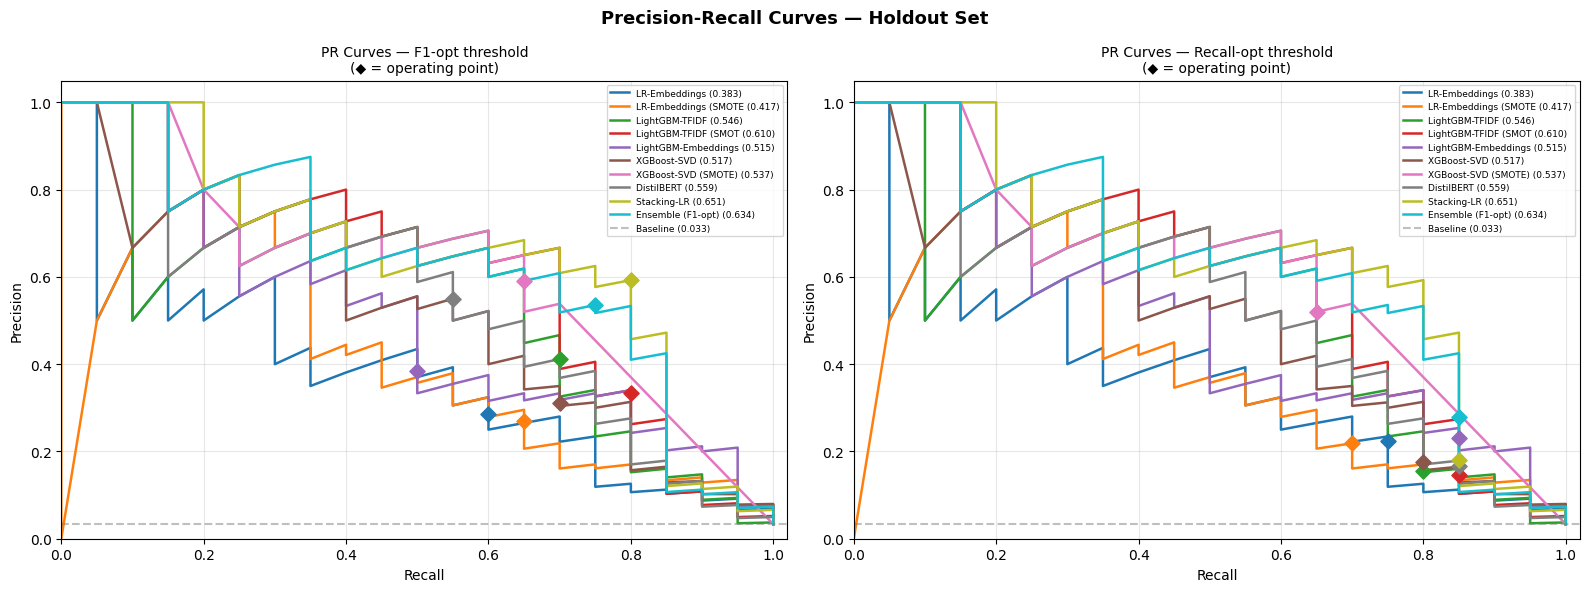

Saved: pr_curves_all_models.png


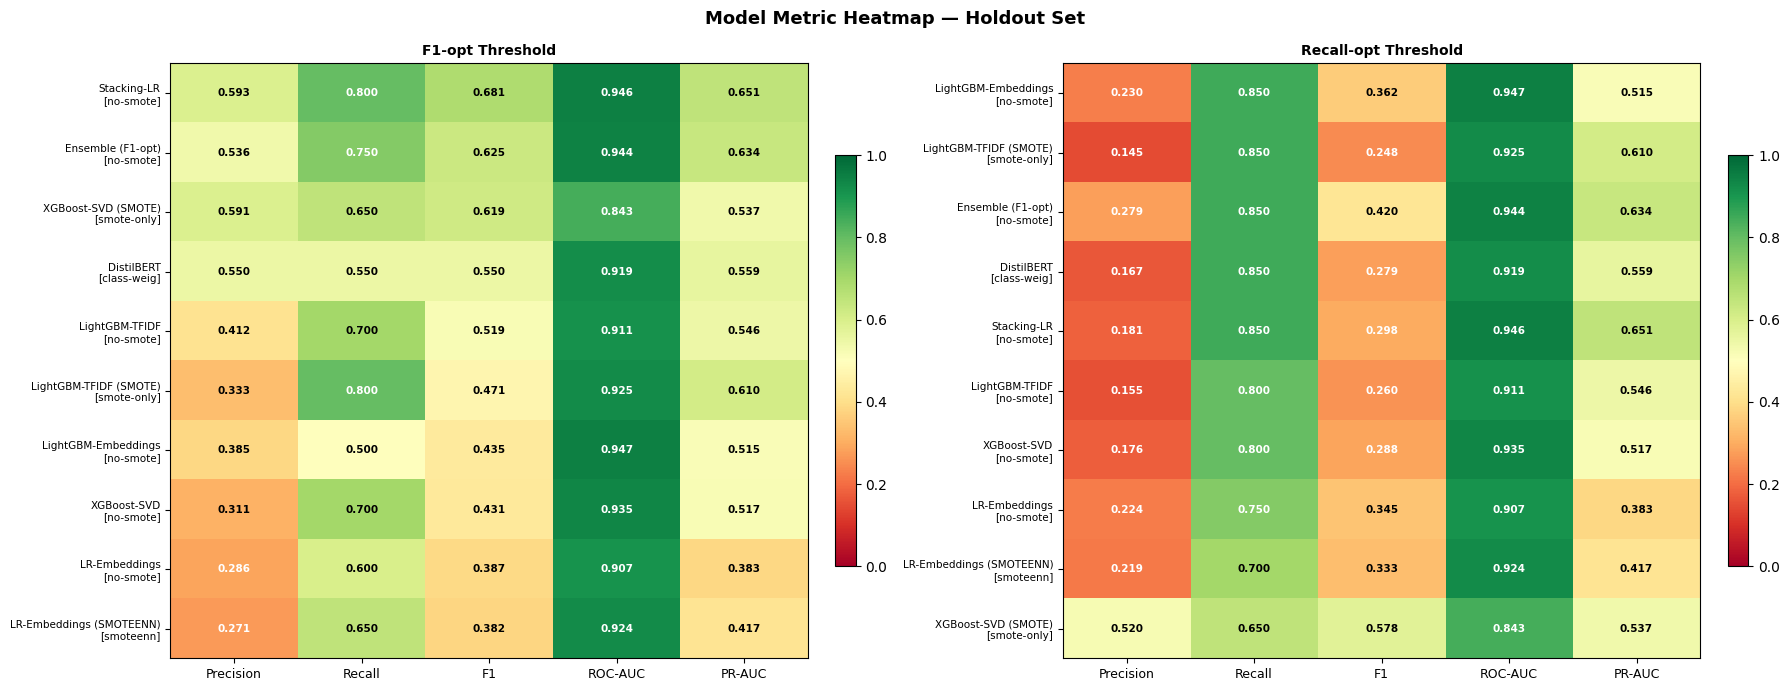

Saved: metric_heatmap_all_models.png
Saved: classification_full_reports.xlsx


In [18]:

# ══════════════════════════════════════════════════════════════════════════
# DETAILED CLASSIFICATION REPORT — Every Model + Both Thresholds
# Shows precision / recall / f1-score / support for each class (No / Yes)
# exactly like sklearn's classification_report, for every model we trained
# ══════════════════════════════════════════════════════════════════════════

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ── All models with their holdout probabilities and both thresholds ────────
ALL_MODELS = [
    # (display_name,              probability_array,   f1_thresh,   rec_thresh,  tag)
    ('LR-Embeddings',             prob_lr_ho,          tf1_lr,      trec_lr,     'no-smote'),
    ('LR-Embeddings (SMOTEENN)',  prob_lr_sm_ho,       tf1_lr_sm,   trec_lr_sm,  'smoteenn'),
    ('LightGBM-TFIDF',            prob_lgbm_ho,        tf1_lgbm,    trec_lgbm,   'no-smote'),
    ('LightGBM-TFIDF (SMOTE)',    prob_lgbm_sm_ho,     tf1_lgbm_sm, trec_lgbm_sm,'smote-only'),
    ('LightGBM-Embeddings',       prob_lgbm_emb_ho,    tf1_lgbm_emb,trec_lgbm_emb,'no-smote'),
    ('XGBoost-SVD',               prob_xgb_ho,         tf1_xgb,     trec_xgb,    'no-smote'),
    ('XGBoost-SVD (SMOTE)',       prob_xgb_sm_ho,      tf1_xgb_sm,  trec_xgb_sm, 'smote-only'),
    ('DistilBERT',                prob_bert_ho,        tf1_bert,    trec_bert,   'class-weight'),
    ('Stacking-LR',               prob_stack_ho,       tf1_stack,   trec_stack,  'no-smote'),
    ('Ensemble (F1-opt)',         prob_ens_ho,         tf1_ens,     trec_ens,    'no-smote'),
]

SEP  = '═' * 72
sep2 = '─' * 72

def print_full_report(name, tag, y_true, y_prob, threshold, mode_label):
    y_pred = (y_prob >= threshold).astype(int)
    tp = int(((y_pred==1) & (y_true==1)).sum())
    fp = int(((y_pred==1) & (y_true==0)).sum())
    fn = int(((y_pred==0) & (y_true==1)).sum())
    tn = int(((y_pred==0) & (y_true==0)).sum())
    try:
        roc = roc_auc_score(y_true, y_prob)
    except Exception:
        roc = float('nan')

    print(f'\n{SEP}')
    print(f'  {name}  [{tag}]  —  threshold: {threshold:.4f}  ({mode_label})')
    print(SEP)
    print(classification_report(y_true, y_pred,
                                 target_names=['No (0)', 'Yes (1)'],
                                 digits=3, zero_division=0))
    print(f'  Confusion Matrix:')
    print(f'                  Predicted No   Predicted Yes')
    print(f'  Actual No          {tn:6d}         {fp:6d}')
    print(f'  Actual Yes         {fn:6d}         {tp:6d}')
    print(f'\n  TP={tp}  FP={fp}  FN={fn}  TN={tn}')
    print(f'  ROC-AUC:   {roc:.4f}')
    print(f'  PR-AUC:    {average_precision_score(y_true, y_prob):.4f}')
    print(sep2)
    return {
        'model': name, 'tag': tag, 'mode': mode_label,
        'threshold': threshold,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision_yes': tp/(tp+fp) if (tp+fp)>0 else 0,
        'recall_yes':    tp/(tp+fn) if (tp+fn)>0 else 0,
        'f1_yes':        2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0,
        'roc_auc': roc,
        'pr_auc':  average_precision_score(y_true, y_prob),
    }

# ── Print full reports for EVERY model at BOTH thresholds ─────────────────
print('\n\n' + SEP)
print('  CLASSIFICATION REPORTS — HOLDOUT SET (598 rows, 20 Important Events)')
print(SEP)
print('  Each model shown at two operating points:')
print('  [F1-opt]     — threshold that maximises F1 score')
print('  [Recall-opt] — threshold that maximises recall (min precision=0.20)')
print(SEP)

all_rows = []
for name, prob, tf1, trec, tag in ALL_MODELS:
    r1 = print_full_report(name, tag, y_ho, prob, tf1,  'F1-opt')
    r2 = print_full_report(name, tag, y_ho, prob, trec, 'Recall-opt')
    all_rows.extend([r1, r2])

# ── Master comparison table ────────────────────────────────────────────────
print(f'\n\n{SEP}')
print('  MASTER COMPARISON TABLE — F1-OPTIMISED THRESHOLD')
print(SEP)
df_rep = pd.DataFrame(all_rows)
f1_rows = df_rep[df_rep['mode']=='F1-opt'].sort_values('f1_yes', ascending=False)
print(f'\n  {"Model":<32} {"Tag":<14} {"Prec":>6} {"Recall":>7} {"F1":>6} {"ROC":>6} {"PR-AUC":>7} {"TP":>4} {"FP":>4} {"FN":>4}')
print('  ' + '-'*100)
for _, row in f1_rows.iterrows():
    print(f'  {row["model"]:<32} {row["tag"]:<14} '
          f'{row["precision_yes"]:>6.3f} {row["recall_yes"]:>7.3f} '
          f'{row["f1_yes"]:>6.3f} {row["roc_auc"]:>6.3f} '
          f'{row["pr_auc"]:>7.3f} {int(row["tp"]):>4} '
          f'{int(row["fp"]):>4} {int(row["fn"]):>4}')

print(f'\n\n  MASTER COMPARISON TABLE — RECALL-OPTIMISED THRESHOLD')
print('  ' + '-'*100)
rec_rows = df_rep[df_rep['mode']=='Recall-opt'].sort_values(
    ['recall_yes','f1_yes'], ascending=False)
print(f'  {"Model":<32} {"Tag":<14} {"Prec":>6} {"Recall":>7} {"F1":>6} {"ROC":>6} {"PR-AUC":>7} {"TP":>4} {"FP":>4} {"FN":>4}')
print('  ' + '-'*100)
for _, row in rec_rows.iterrows():
    print(f'  {row["model"]:<32} {row["tag"]:<14} '
          f'{row["precision_yes"]:>6.3f} {row["recall_yes"]:>7.3f} '
          f'{row["f1_yes"]:>6.3f} {row["roc_auc"]:>6.3f} '
          f'{row["pr_auc"]:>7.3f} {int(row["tp"]):>4} '
          f'{int(row["fp"]):>4} {int(row["fn"]):>4}')

print(f'\n  Holdout set: {int(y_ho.sum())} Important Events (Yes) out of {len(y_ho)} total records')
print(f'  TP = caught Important Events | FP = false alarms | FN = missed Important Events')

# ── Confusion matrix grid — all models at F1-opt ──────────────────────────
n_models = len(ALL_MODELS)
ncols    = 5
nrows    = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 3.8, nrows * 3.5))
axes = axes.flatten()
fig.suptitle('Confusion Matrices — Holdout (F1-optimised threshold)',
             fontsize=13, fontweight='bold', y=1.01)

for idx, (name, prob, tf1, trec, tag) in enumerate(ALL_MODELS):
    y_pred = (prob >= tf1).astype(int)
    cm     = confusion_matrix(y_ho, y_pred)
    ax     = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred:No','Pred:Yes'],
                yticklabels=['True:No','True:Yes'],
                cbar=False, annot_kws={'size':11, 'weight':'bold'})
    tp = cm[1,1]; fp = cm[0,1]; fn = cm[1,0]
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0
    short_name = name[:22]
    ax.set_title(f'{short_name}\n[{tag[:10]}]\nP={prec:.2f} R={rec:.2f} F1={f1:.2f}',
                 fontsize=7.5, pad=3)
    ax.tick_params(labelsize=7)

# Hide unused axes
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: confusion_matrices_all_models.png')

# ── PR Curves — all models on one chart ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Precision-Recall Curves — Holdout Set', fontsize=13, fontweight='bold')

COLORS = plt.cm.tab10(np.linspace(0, 1, len(ALL_MODELS)))

for ax_idx, mode_label, thresh_col in [(0,'F1-opt',2), (1,'Recall-opt',3)]:
    ax = axes[ax_idx]
    for cidx, (name, prob, tf1, trec, tag) in enumerate(ALL_MODELS):
        thresh = tf1 if mode_label == 'F1-opt' else trec
        p, r, _ = precision_recall_curve(y_ho, prob)
        pr_auc  = average_precision_score(y_ho, prob)
        ax.plot(r, p, lw=1.8, color=COLORS[cidx],
                label=f'{name[:20]} ({pr_auc:.3f})')
        # Mark operating point
        y_pred = (prob >= thresh).astype(int)
        op_rec  = recall_score(y_ho, y_pred, zero_division=0)
        op_prec = precision_score(y_ho, y_pred, zero_division=0)
        ax.scatter(op_rec, op_prec, color=COLORS[cidx], s=60,
                   zorder=5, marker='D')

    ax.axhline(y_ho.mean(), ls='--', color='gray', alpha=0.5,
               label=f'Baseline ({y_ho.mean():.3f})')
    ax.set_xlabel('Recall', fontsize=10)
    ax.set_ylabel('Precision', fontsize=10)
    ax.set_title(f'PR Curves — {mode_label} threshold\n(◆ = operating point)',
                 fontsize=10)
    ax.legend(fontsize=6.5, loc='upper right',
              bbox_to_anchor=(1.0, 1.0), ncol=1)
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pr_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pr_curves_all_models.png')

# ── Summary heatmap: all metrics × all models ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Metric Heatmap — Holdout Set', fontsize=13, fontweight='bold')

for ax_idx, (mode_label, sort_col) in enumerate([('F1-opt','f1_yes'),
                                                   ('Recall-opt','recall_yes')]):
    sub = df_rep[df_rep['mode']==mode_label].copy()
    sub['label'] = sub['model'].str[:24] + '\n[' + sub['tag'].str[:10] + ']'
    sub = sub.sort_values(sort_col, ascending=False)
    heat_cols = ['precision_yes','recall_yes','f1_yes','roc_auc','pr_auc']
    heat_labels = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
    mat = sub[heat_cols].values

    ax = axes[ax_idx]
    im = ax.imshow(mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(heat_labels)))
    ax.set_xticklabels(heat_labels, fontsize=9)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['label'].values, fontsize=7.5)
    ax.set_title(f'{mode_label} Threshold', fontsize=10, fontweight='bold')
    # Annotate cells
    for ri in range(len(sub)):
        for ci in range(len(heat_cols)):
            val = mat[ri, ci]
            ax.text(ci, ri, f'{val:.3f}',
                    ha='center', va='center',
                    fontsize=7.5, fontweight='bold',
                    color='black' if 0.3 < val < 0.75 else 'white')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

plt.tight_layout()
plt.savefig('metric_heatmap_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: metric_heatmap_all_models.png')

# Save full report to Excel
df_rep.to_excel('classification_full_reports.xlsx', index=False)
print('Saved: classification_full_reports.xlsx')


In [19]:
# ── Error analysis + Save ─────────────────────────────────────────────────
holdout_df = df_hold[['Description 1','notes_problem_desc','Important Event']].copy()
holdout_df['true_label']    = y_ho
holdout_df['prob_lr_emb']   = prob_lr_ho
holdout_df['prob_lgbm']     = prob_lgbm_ho
holdout_df['prob_lgbm_emb'] = prob_lgbm_emb_ho
holdout_df['prob_bert']     = prob_bert_ho
holdout_df['prob_stack']    = prob_stack_ho
holdout_df['prob_ensemble'] = prob_ens_ho
holdout_df['pred_f1_opt']   = (prob_ens_ho>=tf1_ens).astype(int)
holdout_df['pred_rec_opt']  = (prob_ens_ho>=trec_ens).astype(int)

fn = holdout_df[(holdout_df['true_label']==1)&(holdout_df['pred_f1_opt']==0)]
fp = holdout_df[(holdout_df['true_label']==0)&(holdout_df['pred_f1_opt']==1)]
print(f'Ensemble F1-opt  — FN: {len(fn)}  FP: {len(fp)}')
fn2= holdout_df[(holdout_df['true_label']==1)&(holdout_df['pred_rec_opt']==0)]
fp2= holdout_df[(holdout_df['true_label']==0)&(holdout_df['pred_rec_opt']==1)]
print(f'Ensemble Rec-opt — FN: {len(fn2)}  FP: {len(fp2)}')
print('\nFalse Negatives (F1-opt):')
print(fn[['Description 1','prob_ensemble','prob_bert','prob_lgbm']].to_string())

with pd.ExcelWriter(OUTPUT_PATH, engine='openpyxl') as writer:
    df_ho.sort_values(['mode','f1'],ascending=[True,False]).to_excel(writer,sheet_name='Holdout_Results',index=False)
    df_dev_res.sort_values(['mode','f1'],ascending=[True,False]).to_excel(writer,sheet_name='Dev_OOF_Results',index=False)
    holdout_df.to_excel(writer,sheet_name='Holdout_Predictions',index=False)
    fn.to_excel(writer,sheet_name='FalseNegatives',index=False)
    fp.to_excel(writer,sheet_name='FalsePositives',index=False)

print(f'\nSaved → {OUTPUT_PATH}')
print('\n=== FINAL SUMMARY ===')
best   = df_ho[f1m].sort_values('f1',ascending=False).iloc[0]
best_r = df_ho[recm].sort_values(['recall','f1'],ascending=False).iloc[0]
print(f'Best F1:     {best["model"]} [{best["smote"]}]  F1={best["f1"]:.3f}  Recall={best["recall"]:.3f}  Prec={best["precision"]:.3f}')
print(f'Best Recall: {best_r["model"]} [{best_r["smote"]}]  Recall={best_r["recall"]:.3f}  F1={best_r["f1"]:.3f}')
print(f'\nTarget to beat: DistilBERT F1=0.684  recall=0.65  (old code)')

Ensemble F1-opt  — FN: 5  FP: 13
Ensemble Rec-opt — FN: 3  FP: 44

False Negatives (F1-opt):
                                                                                                           Description 1  prob_ensemble  prob_bert  prob_lgbm
21                                 Lights flickering (ball lights) one section of the light bulb has blown. (0FE SEND 00       0.074794   0.001940   0.041401
100  Death:Alarms/No Sound: No sound on the monitor in the nurses station:No Malfunction/ur uLLReplaced Euternal Speaker       0.296947   0.031755   0.247724
239                                                                             uLS Auto Failure  - Pacing Failure on PM       0.121045   0.002311   0.000263
546                                          0/uDFM0 Defibrillator/Monitor/cuomer feels that the delivered energy is low       0.129885   0.003004   0.007933
562                                                                                                    Duplicate of P

SHAP version: 0.51.0
TF-IDF + numeric feature names: 2462
Embedding + numeric feature names: 3902
Stacking meta-learner feature names: 16

[1/3] Computing SHAP for LightGBM-TFIDF...
Top 20 features — LightGBM TF-IDF:
         feature  mean_shap
desc1_word_count   0.401478
   notes:consued   0.291513
        prob:not   0.277724
    notes:repair   0.273665
desc2_word_count   0.265431
      notes:test   0.263577
     hour_of_day   0.259850
days_since_start   0.258412
     notes:parts   0.207904
     notes:order   0.197253
    desc:patient   0.178454
      notes:part   0.158886
  notes:replaced   0.158014
       desc:does   0.150191
    desc:battery   0.147384
     day_of_week   0.138041
       desc:test   0.133320
   notes:service   0.121756
  notes:customer   0.111076
      desc:power   0.106004

[2/3] Computing SHAP for LightGBM-Embeddings (numeric part)...
Top 20 numeric features — LightGBM Embeddings:
                feature  mean_shap
       notes_char_count   0.043600
       desc1_w

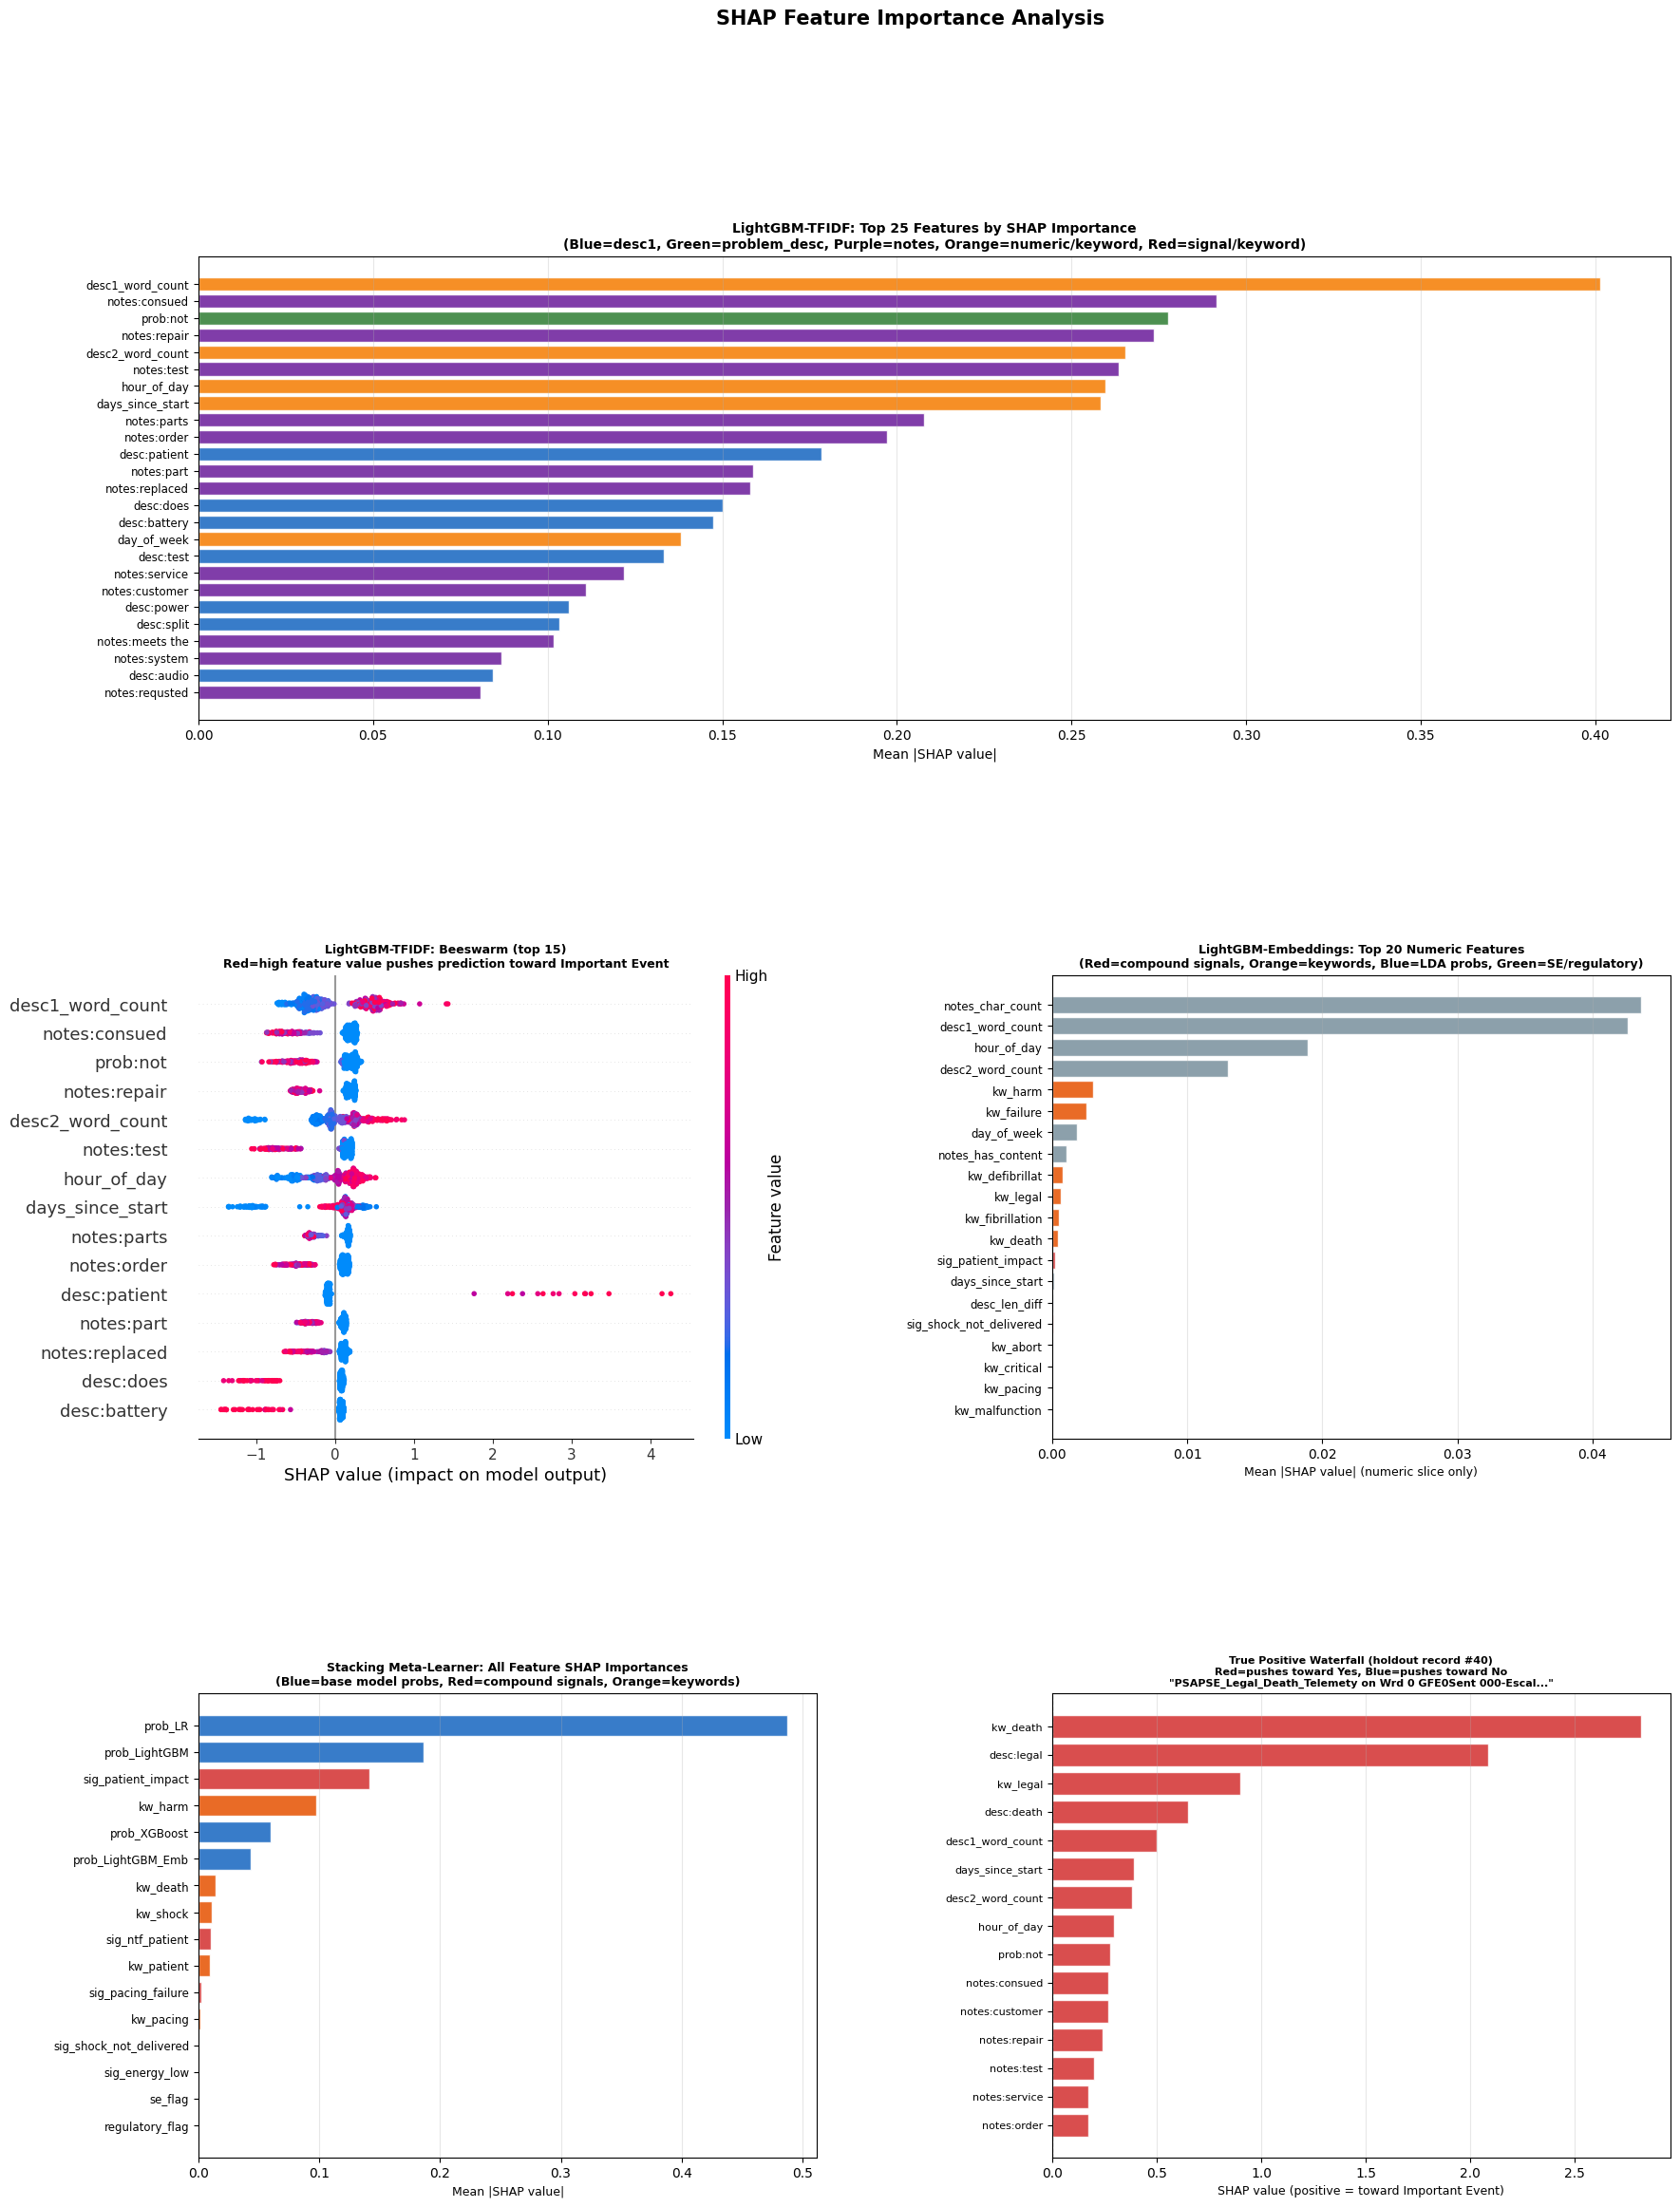

Saved: shap_analysis.png

Generating keyword signal SHAP analysis...

Keyword/Signal SHAP by class (holdout):
                feature  avg_shap_yes   avg_shap_no  abs_shap_all
               kw_death      0.722347 -1.335996e-02      0.037701
               kw_shock      0.059855  2.614378e-03      0.029483
               kw_legal      0.132335 -4.829530e-04      0.011147
           kw_emergency     -0.006069 -6.032030e-05      0.010324
             kw_deliver      0.001812 -5.756512e-04      0.007793
             kw_patient     -0.002086  8.072567e-04      0.004251
     sig_patient_impact      0.008058 -3.124698e-04      0.002952
            kw_incident     -0.000266 -1.594357e-04      0.000840
         kw_defibrillat     -0.000088 -1.222463e-04      0.000736
       kw_investigation      0.000207  6.636246e-05      0.000712
              kw_safety      0.000431  1.718876e-04      0.000240
sig_shock_not_delivered     -0.000088 -8.355797e-05      0.000235
             kw_failure      0.0

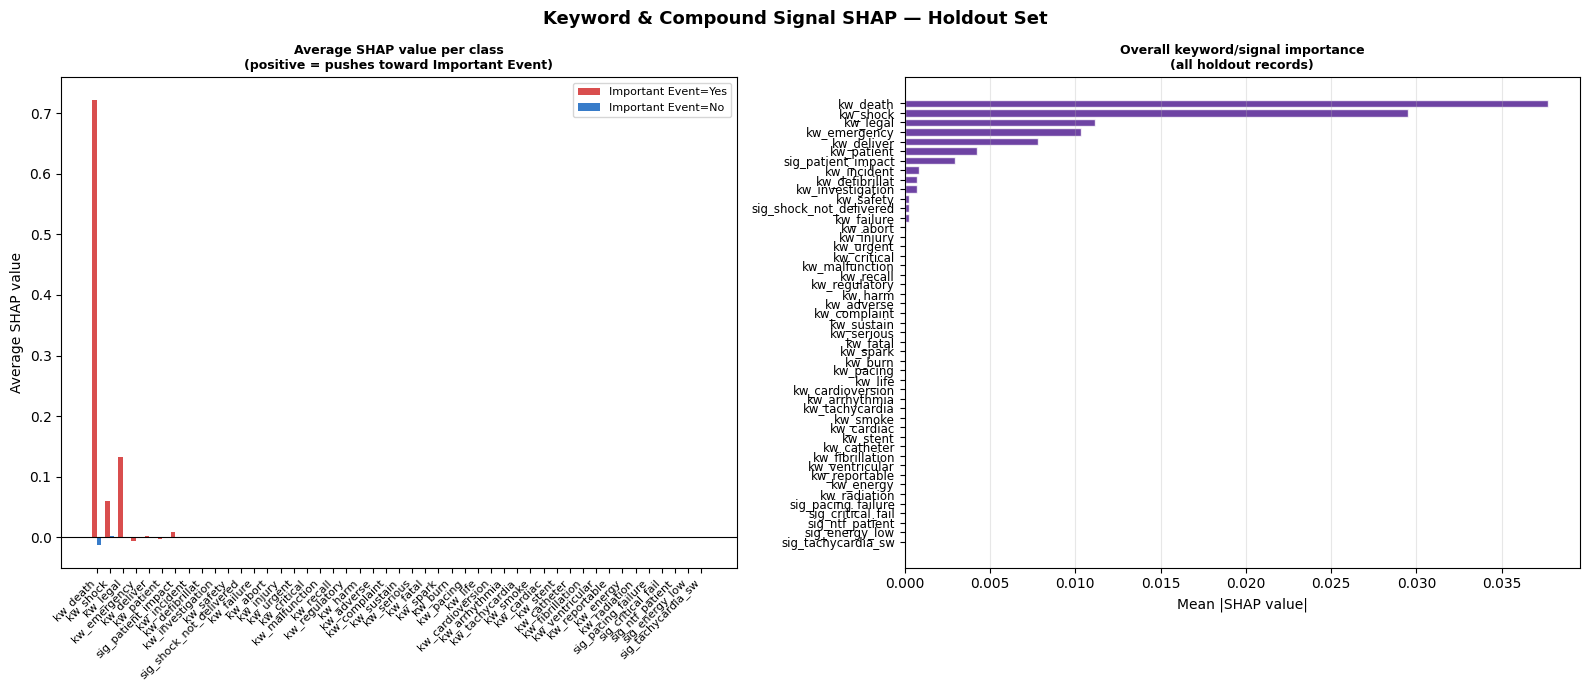

Saved: shap_keywords.png

Saved: shap_analysis.xlsx

=== SHAP ANALYSIS COMPLETE ===
Files saved: shap_analysis.png, shap_keywords.png, shap_analysis.xlsx


In [20]:
# ══════════════════════════════════════════════════════════════════════════
# SHAP ANALYSIS — Feature Importance Across Models
# ══════════════════════════════════════════════════════════════════════════
#
# Variables available from previous cells:
#   lgbm_m        — LightGBM trained on X_sp_dev (TF-IDF sparse)
#   lgbm_emb      — LightGBM trained on X_dev (embeddings + numeric)
#   xgb_m         — CalibratedClassifierCV wrapping XGBoost (X_svd_dev)
#   meta_lr_m     — Stacking meta-learner (meta_dev features)
#   X_sp_dev      — sparse TF-IDF + numeric  (3384, 2462)
#   X_dev         — dense embeddings + numeric (3384, 3902)
#   X_svd_dev     — SVD-compressed TF-IDF (3384, 150)
#   X_sp_hold     — holdout sparse
#   X_hold        — holdout dense
#   num_dev       — numeric feature DataFrame (keyword flags, signals etc.)
#   num_hold      — holdout numeric
#   kw_cols       — keyword column names used in stacking
#   vec_d,p,g,r,n — TF-IDF vectorisers for each text stream
#   y_hold, y_ho  — holdout labels
#
# SHAP is applied to:
#   1. LightGBM on TF-IDF  → TreeExplainer → top TF-IDF tokens + numeric
#   2. LightGBM on Embeddings → TreeExplainer → top numeric features
#      (embedding dims are not interpretable; we separate numeric part)
#   3. Stacking meta-learner → LinearExplainer → base model probs + keywords
#
# !pip install shap  (if not already installed)

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

print('SHAP version:', shap.__version__)

# ── Feature name arrays ───────────────────────────────────────────────────
# TF-IDF sparse feature names (2462 total)
tfidf_names = (
    [f'desc:{n}'  for n in vec_d.get_feature_names_out()] +
    [f'prob:{n}'  for n in vec_p.get_feature_names_out()] +
    [f'diag:{n}'  for n in vec_g.get_feature_names_out()] +
    [f'resol:{n}' for n in vec_r.get_feature_names_out()] +
    [f'notes:{n}' for n in vec_n.get_feature_names_out()] +
    list(num_dev.columns)      # numeric columns appended at end
)
print(f'TF-IDF + numeric feature names: {len(tfidf_names)}')
assert len(tfidf_names) == X_sp_dev.shape[1], \
    f'Name count mismatch: {len(tfidf_names)} vs {X_sp_dev.shape[1]}'

# Embedding + numeric feature names (3902 total)
# Embedding dims are not interpretable — label them by stream index
n_emb = X_dev.shape[1] - num_dev.shape[1]   # 3840 embedding dims
emb_names = [f'emb_desc1_{i}'  for i in range(768)] + \
            [f'emb_prob_{i}'   for i in range(768)] + \
            [f'emb_diag_{i}'   for i in range(768)] + \
            [f'emb_resol_{i}'  for i in range(768)] + \
            [f'emb_desc2_{i}'  for i in range(768)] + \
            list(num_dev.columns)
print(f'Embedding + numeric feature names: {len(emb_names)}')

# Stacking meta-learner feature names
meta_names = ['prob_LR', 'prob_LightGBM', 'prob_XGBoost', 'prob_LightGBM_Emb'] + kw_cols
print(f'Stacking meta-learner feature names: {len(meta_names)}')

# ══════════════════════════════════════════════════════════════════════════
# 1. SHAP — LightGBM on TF-IDF (most interpretable: real token names)
# ══════════════════════════════════════════════════════════════════════════
print('\n[1/3] Computing SHAP for LightGBM-TFIDF...')

# Convert sparse to dense for SHAP (sample for speed)
np.random.seed(42)
sample_idx   = np.random.choice(X_sp_dev.shape[0], min(500, X_sp_dev.shape[0]), replace=False)
X_shap_lgbm  = pd.DataFrame(
    X_sp_dev[sample_idx].toarray(),
    columns=tfidf_names
)

explainer_lgbm = shap.TreeExplainer(lgbm_m)
shap_lgbm      = explainer_lgbm.shap_values(X_shap_lgbm)

# shap_values returns list [class0, class1] for binary classification
sv_lgbm = shap_lgbm[1] if isinstance(shap_lgbm, list) else shap_lgbm

# Mean absolute SHAP per feature
mean_shap_lgbm = np.abs(sv_lgbm).mean(axis=0)
shap_df_lgbm   = pd.DataFrame({
    'feature':    tfidf_names,
    'mean_shap':  mean_shap_lgbm,
}).sort_values('mean_shap', ascending=False)

print('Top 20 features — LightGBM TF-IDF:')
print(shap_df_lgbm.head(20).to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════
# 2. SHAP — LightGBM on Embeddings (focus on interpretable numeric part)
# ══════════════════════════════════════════════════════════════════════════
print('\n[2/3] Computing SHAP for LightGBM-Embeddings (numeric part)...')

# Extract only the numeric portion of X_dev for interpretable SHAP
# Embedding dims 0-3839 are not human-readable; numeric dims 3840-3901 are
numeric_start = n_emb   # = 3840
X_num_dev   = X_dev[:, numeric_start:]
X_num_hold  = X_hold[:, numeric_start:]

sample_idx2  = np.random.choice(X_dev.shape[0], min(500, X_dev.shape[0]), replace=False)
X_shap_num   = pd.DataFrame(X_num_dev[sample_idx2], columns=list(num_dev.columns))

# For LightGBM-emb we use the full X_dev as input — extract SHAP for numeric slice
X_shap_full   = pd.DataFrame(X_dev[sample_idx2], columns=emb_names)
explainer_emb = shap.TreeExplainer(lgbm_emb)
shap_emb      = explainer_emb.shap_values(X_shap_full)

sv_emb = shap_emb[1] if isinstance(shap_emb, list) else shap_emb

# Only look at the numeric slice (last num_dev.shape[1] columns)
sv_num_only   = sv_emb[:, numeric_start:]
mean_shap_num = np.abs(sv_num_only).mean(axis=0)
shap_df_num   = pd.DataFrame({
    'feature':   list(num_dev.columns),
    'mean_shap': mean_shap_num,
}).sort_values('mean_shap', ascending=False)

print('Top 20 numeric features — LightGBM Embeddings:')
print(shap_df_num.head(20).to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════
# 3. SHAP — Stacking Meta-Learner (LinearExplainer)
# ══════════════════════════════════════════════════════════════════════════
print('\n[3/3] Computing SHAP for Stacking Meta-Learner...')

meta_df = pd.DataFrame(meta_dev, columns=meta_names)
explainer_stack = shap.LinearExplainer(meta_lr_m, meta_df)
shap_stack      = explainer_stack.shap_values(meta_df)

sv_stack = shap_stack[1] if isinstance(shap_stack, list) else shap_stack
mean_shap_stack = np.abs(sv_stack).mean(axis=0)
shap_df_stack   = pd.DataFrame({
    'feature':   meta_names,
    'mean_shap': mean_shap_stack,
}).sort_values('mean_shap', ascending=False)

print('All Stacking features ranked by SHAP:')
print(shap_df_stack.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════
# VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════
print('\nGenerating SHAP plots...')

fig = plt.figure(figsize=(20, 26))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.38)
fig.suptitle('SHAP Feature Importance Analysis', fontsize=15, fontweight='bold')

# ── Plot 1: LightGBM-TFIDF — top 25 features (bar) ───────────────────────
ax1 = fig.add_subplot(gs[0, :])   # full width
top25_lgbm = shap_df_lgbm.head(25)
colors = ['#d32f2f' if 'kw_' in f or 'sig_' in f else
          '#1565C0' if f.startswith('desc:') else
          '#2E7D32' if f.startswith('prob:') else
          '#6A1B9A' if f.startswith('notes:') else '#F57C00'
          for f in top25_lgbm['feature']]
bars = ax1.barh(range(len(top25_lgbm)), top25_lgbm['mean_shap'].values,
                color=colors, alpha=0.85, edgecolor='white')
ax1.set_yticks(range(len(top25_lgbm)))
ax1.set_yticklabels(top25_lgbm['feature'].values, fontsize=8.5)
ax1.set_xlabel('Mean |SHAP value|', fontsize=10)
ax1.set_title('LightGBM-TFIDF: Top 25 Features by SHAP Importance\n'
              '(Blue=desc1, Green=problem_desc, Purple=notes, Orange=numeric/keyword, Red=signal/keyword)',
              fontsize=10, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# ── Plot 2: LightGBM-TFIDF SHAP beeswarm (summary plot) ──────────────────
ax2 = fig.add_subplot(gs[1, 0])
top15_idx = [tfidf_names.index(f) for f in shap_df_lgbm.head(15)['feature'].tolist()
             if f in tfidf_names]
shap.summary_plot(
    sv_lgbm[:, top15_idx],
    X_shap_lgbm.iloc[:, top15_idx],
    plot_type='dot',
    max_display=15,
    show=False,
    plot_size=None,
    color_bar=True,
)
ax_beeswarm = plt.gca()
ax_beeswarm.set_title('LightGBM-TFIDF: Beeswarm (top 15)\nRed=high feature value pushes prediction toward Important Event',
                       fontsize=9, fontweight='bold')
plt.sca(ax2)   # refocus

# ── Plot 3: Numeric features bar — LightGBM Embeddings ───────────────────
ax3 = fig.add_subplot(gs[1, 1])
top20_num = shap_df_num.head(20)
num_colors = ['#d32f2f' if 'sig_' in f else
              '#e65100' if 'kw_'  in f else
              '#1565C0' if 'lda_' in f else
              '#2E7D32' if 'se_'  in f or 'reg' in f else '#78909C'
              for f in top20_num['feature']]
ax3.barh(range(len(top20_num)), top20_num['mean_shap'].values,
         color=num_colors, alpha=0.85, edgecolor='white')
ax3.set_yticks(range(len(top20_num)))
ax3.set_yticklabels(top20_num['feature'].values, fontsize=8.5)
ax3.set_xlabel('Mean |SHAP value| (numeric slice only)', fontsize=9)
ax3.set_title('LightGBM-Embeddings: Top 20 Numeric Features\n'
              '(Red=compound signals, Orange=keywords, Blue=LDA probs, Green=SE/regulatory)',
              fontsize=9, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# ── Plot 4: Stacking meta-learner — all features ──────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
stack_colors = ['#1565C0' if 'prob_' in f else
                '#d32f2f' if 'sig_'  in f else '#e65100'
                for f in shap_df_stack['feature']]
ax4.barh(range(len(shap_df_stack)), shap_df_stack['mean_shap'].values,
         color=stack_colors, alpha=0.85, edgecolor='white')
ax4.set_yticks(range(len(shap_df_stack)))
ax4.set_yticklabels(shap_df_stack['feature'].values, fontsize=8.5)
ax4.set_xlabel('Mean |SHAP value|', fontsize=9)
ax4.set_title('Stacking Meta-Learner: All Feature SHAP Importances\n'
              '(Blue=base model probs, Red=compound signals, Orange=keywords)',
              fontsize=9, fontweight='bold')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)

# ── Plot 5: Waterfall for a randomly chosen Important Event (TP) ──────────
ax5 = fig.add_subplot(gs[2, 1])
# Find a true positive in holdout using lgbm_m
prob_lgbm_hold = lgbm_m.predict_proba(X_sp_hold)[:, 1]
tp_indices = np.where((prob_lgbm_hold >= tf1_lgbm) & (y_ho == 1))[0]

if len(tp_indices) > 0:
    tp_idx = tp_indices[0]
    x_tp   = pd.DataFrame(
        X_sp_hold[tp_idx].toarray(),
        columns=tfidf_names
    )
    shap_tp = explainer_lgbm.shap_values(x_tp)
    sv_tp   = shap_tp[1] if isinstance(shap_tp, list) else shap_tp
    sv_tp   = sv_tp[0]

    # Top 15 contributing features for this record
    contrib_df = pd.DataFrame({
        'feature': tfidf_names,
        'shap':    sv_tp,
    }).reindex(pd.Series(sv_tp).abs().sort_values(ascending=False).index)
    contrib_df = contrib_df.head(15)

    bar_colors = ['#d32f2f' if v > 0 else '#1565C0' for v in contrib_df['shap']]
    ax5.barh(range(len(contrib_df)), contrib_df['shap'].values,
             color=bar_colors, alpha=0.85, edgecolor='white')
    ax5.set_yticks(range(len(contrib_df)))
    ax5.set_yticklabels(contrib_df['feature'].values, fontsize=8)
    ax5.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax5.set_xlabel('SHAP value (positive = toward Important Event)', fontsize=9)
    original_desc = df_hold.iloc[tp_idx].get('Description 1', 'N/A')
    ax5.set_title(f'True Positive Waterfall (holdout record #{tp_idx})\n'
                  f'Red=pushes toward Yes, Blue=pushes toward No\n'
                  f'"{str(original_desc)[:55]}..."',
                  fontsize=8, fontweight='bold')
    ax5.invert_yaxis()
    ax5.grid(axis='x', alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'No true positives found\nin holdout', ha='center', va='center',
             transform=ax5.transAxes, fontsize=12)
    ax5.set_title('True Positive Waterfall', fontsize=9)

plt.savefig('shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_analysis.png')

# ══════════════════════════════════════════════════════════════════════════
# SHAP INTERACTION: keyword signals vs ensemble probability
# ══════════════════════════════════════════════════════════════════════════
print('\nGenerating keyword signal SHAP analysis...')

# Show which keyword/signal features most separate Yes from No on holdout
sig_kw_cols = [c for c in num_dev.columns
               if c.startswith('kw_') or c.startswith('sig_')]

# Compute LightGBM-TFIDF SHAP on full holdout for signal/keyword slice
X_hold_dense = pd.DataFrame(
    X_sp_hold.toarray(),
    columns=tfidf_names
)
shap_hold   = explainer_lgbm.shap_values(X_hold_dense)
sv_hold     = shap_hold[1] if isinstance(shap_hold, list) else shap_hold

# Get indices of keyword/signal columns in the tfidf_names list
# (they are at the end — the numeric columns appended after TF-IDF)
n_tfidf_only = X_sp_dev.shape[1] - num_dev.shape[1]
sig_idx = [i for i, name in enumerate(tfidf_names)
           if any(name == col for col in sig_kw_cols)]

if sig_idx:
    sv_kw   = sv_hold[:, sig_idx]
    kw_names= [tfidf_names[i] for i in sig_idx]

    # Average SHAP by Yes/No class
    kw_shap_yes = sv_kw[y_ho == 1].mean(axis=0)
    kw_shap_no  = sv_kw[y_ho == 0].mean(axis=0)

    kw_df = pd.DataFrame({
        'feature':       kw_names,
        'avg_shap_yes':  kw_shap_yes,
        'avg_shap_no':   kw_shap_no,
        'abs_shap_all':  np.abs(sv_kw).mean(axis=0),
    }).sort_values('abs_shap_all', ascending=False)

    print('\nKeyword/Signal SHAP by class (holdout):')
    print(kw_df.to_string(index=False))

    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
    fig2.suptitle('Keyword & Compound Signal SHAP \u2014 Holdout Set',
                  fontsize=13, fontweight='bold')

    # Left: mean SHAP for Yes vs No
    ax = axes2[0]
    x  = np.arange(len(kw_df))
    w  = 0.35
    ax.bar(x-w/2, kw_df['avg_shap_yes'], w, label='Important Event=Yes', color='#d32f2f', alpha=0.85)
    ax.bar(x+w/2, kw_df['avg_shap_no'],  w, label='Important Event=No',  color='#1565C0', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(kw_df['feature'].values, rotation=45, ha='right', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Average SHAP value')
    ax.set_title('Average SHAP value per class\n(positive = pushes toward Important Event)',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

    # Right: overall mean |SHAP|
    ax = axes2[1]
    ax.barh(range(len(kw_df)), kw_df['abs_shap_all'].values,
            color='#4a148c', alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(kw_df)))
    ax.set_yticklabels(kw_df['feature'].values, fontsize=8.5)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title('Overall keyword/signal importance\n(all holdout records)',
                 fontsize=9, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('shap_keywords.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: shap_keywords.png')

# ══════════════════════════════════════════════════════════════════════════
# SAVE SHAP SUMMARY TO EXCEL
# ══════════════════════════════════════════════════════════════════════════
with pd.ExcelWriter('shap_analysis.xlsx', engine='openpyxl') as writer:
    shap_df_lgbm.head(50).to_excel(writer, sheet_name='LightGBM_TFIDF_Top50', index=False)
    shap_df_num.to_excel(writer,   sheet_name='LightGBM_Emb_Numeric',  index=False)
    shap_df_stack.to_excel(writer, sheet_name='Stacking_MetaLearner',   index=False)
    if sig_idx:
        kw_df.to_excel(writer, sheet_name='Keywords_Signals_ByClass', index=False)

print('\nSaved: shap_analysis.xlsx')
print('\n=== SHAP ANALYSIS COMPLETE ===')
print('Files saved: shap_analysis.png, shap_keywords.png, shap_analysis.xlsx')